<a href="https://colab.research.google.com/github/spoorthikengol/AI-Medical-imaging/blob/main/hactahon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# ===== Install dependencies (Colab) =====
!pip -q install nibabel SimpleITK scikit-image opencv-python-headless \
    torch torchvision --upgrade \
    sewar pyiqa lpips medpy pycocotools \
    gdown kaggle pandas matplotlib seaborn tqdm monai
print("Installs complete.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 8.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 9.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 4.0 MB/s eta 0:00:0

In [ ]:

import os, sys, glob, json, time, random, shutil, zipfile
import numpy as np
import pandas as pd
import nibabel as nib
import SimpleITK as sitk
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)


Using device: cuda


In [ ]:

# ============================== CONFIG ==================================
from types import SimpleNamespace

CFG = SimpleNamespace(
    # --- Root working dirs ---
    WORK_DIR      = "/content/outputs",
    REPORT_DIR    = "/content/outputs/report_assets",

    # --- Brain MRI: BraTS 2020 (standard training dataset, per problem statement) ---
    # Option A: Kaggle dataset (awsaf49/brats20-dataset-training-validation)
    USE_KAGGLE_BRATS = True,
    KAGGLE_BRATS_SLUG = "awsaf49/brats20-dataset-training-validation",
    BRATS_ROOT     = "/content/data/brats2020",   # populated automatically in Stage 0.3

    # --- Spine MRI: Hackathon-provided dataset (Google Drive) ---
    # Set this to the local path once you've downloaded/synced the shared Drive folder,
    # e.g. after `gdown --folder <link>` or mounting Drive and copying it in.
    SPINE_ROOT      = "/content/data/spine_hackathon",

    # --- Hackathon's own Brain/Spine dataset (normal + pathological, no GT) ---
    # Used ONLY for Stage 1 exploration / Stage 2 preprocessing / Stage 3 enhancement,
    # per the rule "must use Hackathon dataset for Spine; must use BraTS for Brain training".
    HACKATHON_BRAIN_ROOT = "/content/data/hackathon_brain",
    HACKATHON_SPINE_ROOT = "/content/data/spine_hackathon",

    # --- Training params ---
    IMG_SIZE       = 128,     # 2D slice size fed to models
    BATCH_SIZE     = 16,
    ENH_EPOCHS     = 15,
    SEG_EPOCHS     = 25,
    LR             = 1e-3,
    VAL_SPLIT      = 0.15,
    TEST_SPLIT     = 0.15,
)

for d in [CFG.WORK_DIR, CFG.REPORT_DIR,
          f"{CFG.WORK_DIR}/preprocessed", f"{CFG.WORK_DIR}/enhanced",
          f"{CFG.WORK_DIR}/segmented", f"{CFG.WORK_DIR}/checkpoints",
          f"{CFG.WORK_DIR}/coco"]:
    os.makedirs(d, exist_ok=True)

print(json.dumps(vars(CFG), indent=2))


{
  "WORK_DIR": "/content/outputs",
  "REPORT_DIR": "/content/outputs/report_assets",
  "USE_KAGGLE_BRATS": true,
  "KAGGLE_BRATS_SLUG": "awsaf49/brats20-dataset-training-validation",
  "BRATS_ROOT": "/content/data/brats2020",
  "SPINE_ROOT": "/content/data/spine_hackathon",
  "HACKATHON_BRAIN_ROOT": "/content/data/hackathon_brain",
  "HACKATHON_SPINE_ROOT": "/content/data/spine_hackathon",
  "IMG_SIZE": 128,
  "BATCH_SIZE": 16,
  "ENH_EPOCHS": 15,
  "SEG_EPOCHS": 25,
  "LR": 0.001,
  "VAL_SPLIT": 0.15,
  "TEST_SPLIT": 0.15
}


In [ ]:
# 1. Install Kaggle library
!pip install -q kaggle

# 2. Upload your kaggle.json file
from google.colab import files
print("Please upload your kaggle.json file:")
uploaded = files.upload()

# 3. Setup Kaggle credentials directory
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 4. Download the BraTS 2020 Dataset (~4.5 GB)
!kaggle datasets download -d awsaf49/brats20-dataset-training-validation

# 5. Extract the downloaded dataset
import zipfile
import os

print("Extracting dataset...")
with zipfile.ZipFile("brats20-dataset-training-validation.zip", "r") as zip_ref:
    zip_ref.extractall("BraTS2020_Dataset")

print("Done! Files extracted to 'BraTS2020_Dataset/' directory.")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats20-dataset-training-validation
License(s): CC0-1.0
100% 4.16G/4.16G [03:20<00:00, 22.3MB/s]

Extracting dataset...
Done! Files extracted to 'BraTS2020_Dataset/' directory.


In [ ]:

# ----- (b) Hackathon Spine (and Brain) dataset -----
# Recommended: mount Google Drive and place/sync the offline-shared dataset there,
# OR use gdown on the shared folder link given in the problem statement.

from google.colab import drive
drive.mount('/content/drive')

# If you already copied the Hackathon dataset (Brain + Spine folders, NifTI/GZ) into Drive,
# just point these to the right subfolders, e.g.:
# CFG.HACKATHON_BRAIN_ROOT = "/content/drive/MyDrive/Hackathon/Brain_MRI"
# CFG.HACKATHON_SPINE_ROOT = "/content/drive/MyDrive/Hackathon/Spine_MRI"
# CFG.SPINE_ROOT = CFG.HACKATHON_SPINE_ROOT

# Alternatively, download directly via gdown (uncomment and use the Hackathon-shared folder ID):
# !pip -q install -U gdown
# !gdown --folder "https://drive.google.com/drive/folders/19psnKwO4swOQ6BUE2xuPpxu0PyJ3SKM1" -O {CFG.HACKATHON_SPINE_ROOT}

print("Set CFG.HACKATHON_BRAIN_ROOT / CFG.HACKATHON_SPINE_ROOT to your actual dataset paths above,")
print("then re-run the CONFIG cell if you changed them.")


Mounted at /content/drive
Set CFG.HACKATHON_BRAIN_ROOT / CFG.HACKATHON_SPINE_ROOT to your actual dataset paths above,
then re-run the CONFIG cell if you changed them.


In [ ]:

# ----- File discovery helpers -----
NII_EXT = (".nii", ".nii.gz")

def find_nii_files(root):
    files = []
    for dp, _, fnames in os.walk(root):
        for fn in fnames:
            if fn.endswith(NII_EXT):
                files.append(os.path.join(dp, fn))
    return sorted(files)

def guess_modality(fname):
    # Map filename tokens to a standard sub-modality label.
    f = fname.lower()
    if "flair" in f: return "FLAIR"
    if "t1ce" in f or "t1c" in f or "contrast" in f: return "T1c"
    if "t1" in f: return "T1"
    if "t2" in f and "stir" not in f: return "T2"
    if "stir" in f: return "STIR"
    if "seg" in f or "mask" in f or "label" in f: return "SEG"
    return "UNKNOWN"

def load_nii(path):
    img = nib.load(path)
    vol = img.get_fdata().astype(np.float32)
    spacing = img.header.get_zooms()[:3]
    return vol, spacing, img.affine

print("Helper functions ready: find_nii_files(), guess_modality(), load_nii()")


Helper functions ready: find_nii_files(), guess_modality(), load_nii()


In [ ]:

# ----- Build manifest: BraTS (Brain, training std) + Hackathon Brain + Hackathon Spine -----
def build_manifest(root, dataset_tag):
    rows = []
    if not root or not os.path.isdir(root):
        print(f"[WARN] Path not found, skipping: {root}")
        return pd.DataFrame(rows)
    files = find_nii_files(root)
    for fp in files:
        patient = os.path.basename(os.path.dirname(fp))
        modality = guess_modality(os.path.basename(fp))
        rows.append({
            "dataset": dataset_tag,
            "patient": patient,
            "modality": modality,
            "path": fp,
            "filename": os.path.basename(fp),
        })
    return pd.DataFrame(rows)

manifest_brats        = build_manifest(CFG.BRATS_ROOT, "BraTS2020_Brain_train")
manifest_hack_brain   = build_manifest(CFG.HACKATHON_BRAIN_ROOT, "Hackathon_Brain")
manifest_hack_spine   = build_manifest(CFG.HACKATHON_SPINE_ROOT, "Hackathon_Spine")

manifest_all = pd.concat([manifest_brats, manifest_hack_brain, manifest_hack_spine],
                          ignore_index=True)
manifest_all.to_csv(f"{CFG.REPORT_DIR}/dataset_manifest.csv", index=False)
print(manifest_all.groupby(["dataset", "modality"]).size())
manifest_all.head()


[WARN] Path not found, skipping: /content/data/hackathon_brain
[WARN] Path not found, skipping: /content/data/spine_hackathon
dataset                modality
BraTS2020_Brain_train  FLAIR       494
                       SEG         369
                       T1          494
                       T1c         494
                       T2          494
dtype: int64


,dataset,patient,modality,path,filename
0,BraTS2020_Brain_train,BraTS20_Training_001,FLAIR,/content/data/brats2020/BraTS2020_TrainingData...,BraTS20_Training_001_flair.nii
1,BraTS2020_Brain_train,BraTS20_Training_001,SEG,/content/data/brats2020/BraTS2020_TrainingData...,BraTS20_Training_001_seg.nii
2,BraTS2020_Brain_train,BraTS20_Training_001,T1,/content/data/brats2020/BraTS2020_TrainingData...,BraTS20_Training_001_t1.nii
3,BraTS2020_Brain_train,BraTS20_Training_001,T1c,/content/data/brats2020/BraTS2020_TrainingData...,BraTS20_Training_001_t1ce.nii
4,BraTS2020_Brain_train,BraTS20_Training_001,T2,/content/data/brats2020/BraTS2020_TrainingData...,BraTS20_Training_001_t2.nii


In [ ]:

# ----- Sub-modality division per patient (deliverable) -----
def submodality_pivot(df):
    if df.empty: return df
    pivot = df.pivot_table(index="patient", columns="modality", values="path",
                            aggfunc="first")
    return pivot

pivot_brats = submodality_pivot(manifest_brats)
pivot_hack_brain = submodality_pivot(manifest_hack_brain)
pivot_hack_spine = submodality_pivot(manifest_hack_spine)

pivot_brats.to_csv(f"{CFG.REPORT_DIR}/brats_submodality_division.csv")
pivot_hack_brain.to_csv(f"{CFG.REPORT_DIR}/hackathon_brain_submodality_division.csv")
pivot_hack_spine.to_csv(f"{CFG.REPORT_DIR}/hackathon_spine_submodality_division.csv")

print("Brain (BraTS) sub-modality table:")
display(pivot_brats.head())
print("Spine (Hackathon) sub-modality table:")
display(pivot_hack_spine.head())


Brain (BraTS) sub-modality table:


modality,FLAIR,SEG,T1,T1c,T2
patient,,,,,
BraTS20_Training_001,/content/data/brats2020/BraTS2020_TrainingData...,/content/data/brats2020/BraTS2020_TrainingData...,/content/data/brats2020/BraTS2020_TrainingData...,/content/data/brats2020/BraTS2020_TrainingData...,/content/data/brats2020/BraTS2020_TrainingData...
BraTS20_Training_002,/content/data/brats2020/BraTS2020_TrainingData...,/content/data/brats2020/BraTS2020_TrainingData...,/content/data/brats2020/BraTS2020_TrainingData...,/content/data/brats2020/BraTS2020_TrainingData...,/content/data/brats2020/BraTS2020_TrainingData...
BraTS20_Training_003,/content/data/brats2020/BraTS2020_TrainingData...,/content/data/brats2020/BraTS2020_TrainingData...,/content/data/brats2020/BraTS2020_TrainingData...,/content/data/brats2020/BraTS2020_TrainingData...,/content/data/brats2020/BraTS2020_TrainingData...
BraTS20_Training_004,/content/data/brats2020/BraTS2020_TrainingData...,/content/data/brats2020/BraTS2020_TrainingData...,/content/data/brats2020/BraTS2020_TrainingData...,/content/data/brats2020/BraTS2020_TrainingData...,/content/data/brats2020/BraTS2020_TrainingData...
BraTS20_Training_005,/content/data/brats2020/BraTS2020_TrainingData...,/content/data/brats2020/BraTS2020_TrainingData...,/content/data/brats2020/BraTS2020_TrainingData...,/content/data/brats2020/BraTS2020_TrainingData...,/content/data/brats2020/BraTS2020_TrainingData...


Spine (Hackathon) sub-modality table:


""


In [ ]:

# ----- Image property assessment: Contrast, Sharpness, Edge strength, Noise, Mean, Std, Entropy -----
from skimage.filters import sobel
from skimage.measure import shannon_entropy
from skimage.restoration import estimate_sigma

def middle_slice(vol, axis=2):
    idx = vol.shape[axis] // 2
    return np.take(vol, idx, axis=axis)

def normalize01(img):
    img = img.astype(np.float32)
    mn, mx = np.percentile(img, 1), np.percentile(img, 99)
    if mx - mn < 1e-6: return np.zeros_like(img)
    out = (img - mn) / (mx - mn)
    return np.clip(out, 0, 1)

def image_properties(img2d):
    img = normalize01(img2d)
    lap_var = cv2.Laplacian((img * 255).astype(np.uint8), cv2.CV_64F).var()   # sharpness
    edge = sobel(img).mean()                                                    # edge strength
    noise = estimate_sigma(img, channel_axis=None)                              # noise level
    contrast = img.std()
    entropy = shannon_entropy(img)
    return dict(mean=img.mean(), std=img.std(), contrast=contrast,
                sharpness_lapvar=lap_var, edge_strength=edge,
                noise_sigma=noise, entropy=entropy)

def assess_dataframe(df, tag):
    rows = []
    for _, r in tqdm(df.iterrows(), total=len(df), desc=f"Assessing {tag}"):
        if r["modality"] in ("SEG", "UNKNOWN"):
            continue
        try:
            vol, spacing, _ = load_nii(r["path"])
            sl = middle_slice(vol)
            props = image_properties(sl)
            props.update(dataset=r["dataset"], patient=r["patient"],
                         modality=r["modality"], shape=str(vol.shape),
                         spacing=str(tuple(np.round(spacing, 2))))
            rows.append(props)
        except Exception as e:
            print("skip", r["path"], e)
    return pd.DataFrame(rows)

# Run on a manageable sample first (set N=None for full dataset)
N_SAMPLE = 40
props_brats = assess_dataframe(manifest_brats.head(N_SAMPLE) if N_SAMPLE else manifest_brats,
                                "BraTS")
props_hack_spine = assess_dataframe(manifest_hack_spine.head(N_SAMPLE) if N_SAMPLE else manifest_hack_spine,
                                     "Hackathon_Spine")

props_all = pd.concat([props_brats, props_hack_spine], ignore_index=True)
props_all.to_csv(f"{CFG.REPORT_DIR}/stage1_image_property_assessment.csv", index=False)
props_all.groupby(["dataset", "modality"])[["mean","std","contrast",
    "sharpness_lapvar","edge_strength","noise_sigma","entropy"]].mean()


Assessing BraTS:   0%|          | 0/40 [00:00<?, ?it/s]

Assessing Hackathon_Spine: 0it [00:00, ?it/s]

mean       std  contrast  \
dataset               modality                                 
BraTS2020_Brain_train FLAIR     0.183068  0.294919  0.294919   
                      T1        0.220265  0.345254  0.345254   
                      T1c       0.220936  0.343631  0.343631   
                      T2        0.143145  0.238633  0.238633   

                                sharpness_lapvar  edge_strength  noise_sigma  \
dataset               modality                                                 
BraTS2020_Brain_train FLAIR          1252.093885       0.029558     0.023085   
                      T1              845.995825       0.028140     0.014964   
                      T1c            1624.451719       0.029764     0.020194   
                      T2              981.393212       0.027010     0.017259   

                                 entropy  
dataset               modality            
BraTS2020_Brain_train FLAIR     3.237958  
                      T1        3.409699  
                      T1c       3.392702  
                      T2        3.092532

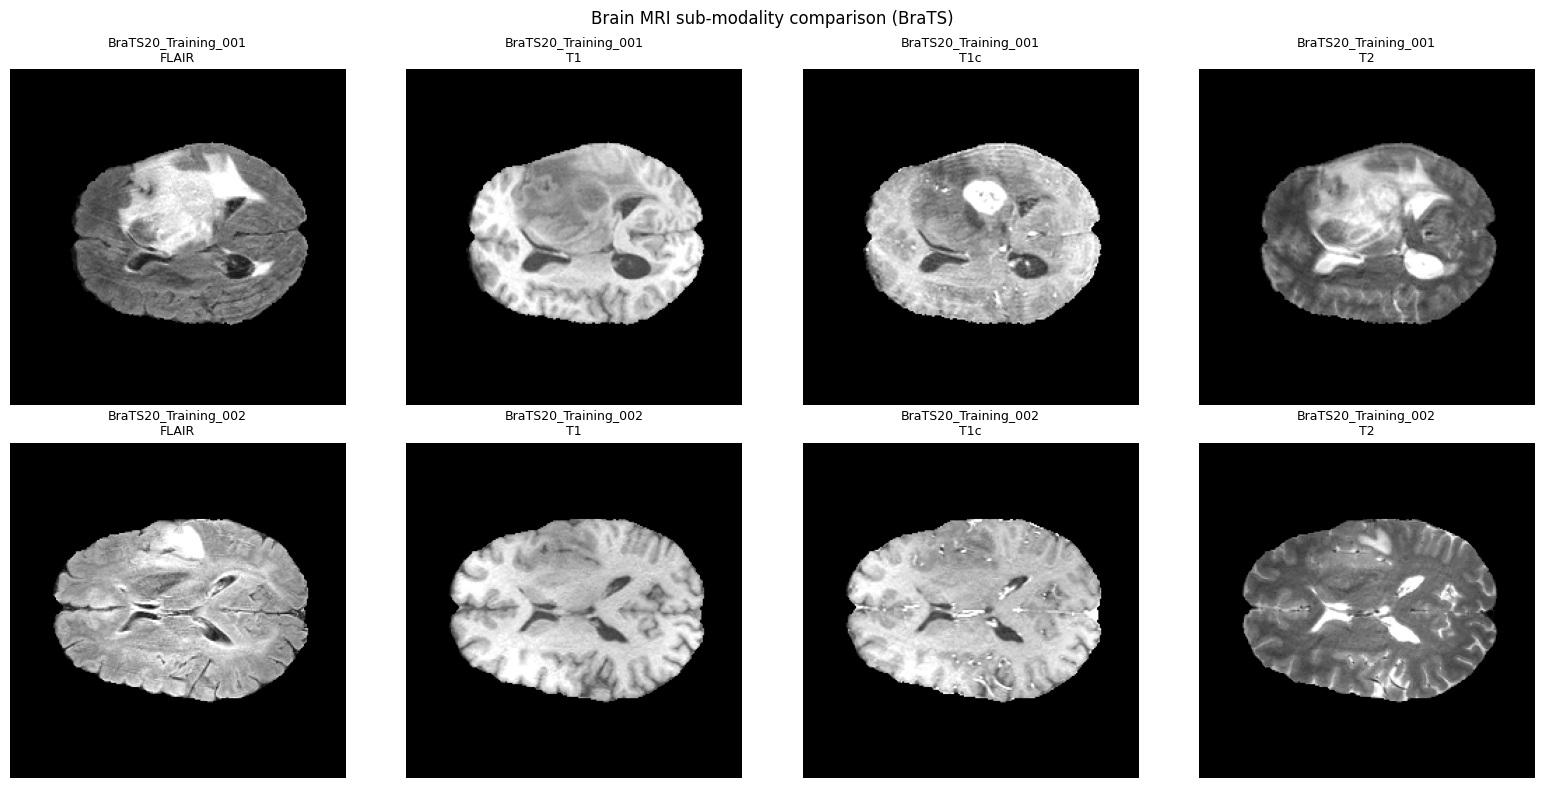

In [ ]:

# ----- Visual comparison across sub-modalities (deliverable figure) -----
def plot_submodalities(pivot_df, title, n_patients=2):
    mods = [m for m in pivot_df.columns if m != "SEG"]
    fig, axes = plt.subplots(n_patients, len(mods), figsize=(4*len(mods), 4*n_patients))
    if n_patients == 1: axes = axes[None, :]
    for i, (patient, row) in enumerate(pivot_df.head(n_patients).iterrows()):
        for j, m in enumerate(mods):
            ax = axes[i, j]
            path = row.get(m)
            if isinstance(path, str) and os.path.exists(path):
                vol, _, _ = load_nii(path)
                ax.imshow(normalize01(middle_slice(vol)), cmap="gray")
            ax.set_title(f"{patient}\n{m}", fontsize=9)
            ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(f"{CFG.REPORT_DIR}/{title.replace(' ','_')}.png", dpi=150)
    plt.show()

if not pivot_brats.empty:
    plot_submodalities(pivot_brats, "Brain MRI sub-modality comparison (BraTS)")
if not pivot_hack_spine.empty:
    plot_submodalities(pivot_hack_spine, "Spine MRI sub-modality comparison (Hackathon)")


In [ ]:

# ----- Dataset challenges discussion (auto-generated notes, deliverable) -----
challenges_md = f'''
### Dataset Challenges (auto-summarized from Stage-1 stats)

- **Intensity non-standardization**: T1/T2/FLAIR/STIR intensities are scanner- and protocol-dependent
  (no absolute units like CT/HU) — mean intensity ranges observed:
  {props_all.groupby("modality")["mean"].agg(["min","max"]).round(3).to_dict()}
- **Noise variability**: estimated noise sigma ranges
  {props_all.groupby("modality")["noise_sigma"].agg(["min","max"]).round(4).to_dict()}
  — motivates modality-specific denoising in Stage 2.
- **Anisotropic voxel spacing** across patients/sequences requires resampling before any 3D/2D model.
- **No ground-truth ROI masks** in the Hackathon dataset (Brain & Spine) — Brain segmentation is
  therefore trained/evaluated on **BraTS 2020** (has masks); Spine segmentation uses weak/pseudo
  labels (Stage 4) since only BraTS is the sanctioned external Brain dataset and Spine must stay
  Hackathon-only.
- **Class imbalance** for pathological ROI (tumor/edema/disc pixels are a small fraction of the volume).
'''
with open(f"{CFG.REPORT_DIR}/stage1_dataset_challenges.md", "w") as f:
    f.write(challenges_md)
print(challenges_md)



### Dataset Challenges (auto-summarized from Stage-1 stats)

- **Intensity non-standardization**: T1/T2/FLAIR/STIR intensities are scanner- and protocol-dependent
  (no absolute units like CT/HU) — mean intensity ranges observed:
  {'min': {'FLAIR': 0.12700000405311584, 'T1': 0.20499999821186066, 'T1c': 0.20900000631809235, 'T2': 0.11800000071525574}, 'max': {'FLAIR': 0.24400000274181366, 'T1': 0.24300000071525574, 'T1c': 0.24500000476837158, 'T2': 0.1589999943971634}}
- **Noise variability**: estimated noise sigma ranges
  {'min': {'FLAIR': 0.0146, 'T1': 0.0107, 'T1c': 0.0172, 'T2': 0.0134}, 'max': {'FLAIR': 0.0358, 'T1': 0.018, 'T1c': 0.0242, 'T2': 0.0247}}
  — motivates modality-specific denoising in Stage 2.
- **Anisotropic voxel spacing** across patients/sequences requires resampling before any 3D/2D model.
- **No ground-truth ROI masks** in the Hackathon dataset (Brain & Spine) — Brain segmentation is
  therefore trained/evaluated on **BraTS 2020** (has masks); Spine segmentatio

In [ ]:

# ----- Train / Val / Test enumeration (deliverable) -----
def make_splits(patients, val_split=CFG.VAL_SPLIT, test_split=CFG.TEST_SPLIT, seed=SEED):
    patients = sorted(list(patients))
    rng = np.random.RandomState(seed)
    rng.shuffle(patients)
    n = len(patients)
    n_test = max(1, int(n * test_split)) if n > 3 else 0
    n_val  = max(1, int(n * val_split)) if n > 3 else 0
    test  = patients[:n_test]
    val   = patients[n_test:n_test+n_val]
    train = patients[n_test+n_val:]
    return {"train": train, "val": val, "test": test}

splits = {
    "BraTS_Brain": make_splits(manifest_brats["patient"].unique()) if not manifest_brats.empty else {},
    "Hackathon_Brain": make_splits(manifest_hack_brain["patient"].unique()) if not manifest_hack_brain.empty else {},
    "Hackathon_Spine": make_splits(manifest_hack_spine["patient"].unique()) if not manifest_hack_spine.empty else {},
}
with open(f"{CFG.REPORT_DIR}/dataset_splits.json", "w") as f:
    json.dump(splits, f, indent=2)

for k, v in splits.items():
    if v:
        print(k, {kk: len(vv) for kk, vv in v.items()})


BraTS_Brain {'train': 346, 'val': 74, 'test': 74}


In [ ]:


# ----- Preprocessing primitives -----

def n4_bias_correction(sitk_img, shrink=4):
    # N4ITK bias field correction (SimpleITK) -- standard MRI-specific denoise/normalize step
    img = sitk.Cast(sitk_img, sitk.sitkFloat32)
    mask = sitk.OtsuThreshold(img, 0, 1, 200)
    shrunk = sitk.Shrink(img, [shrink]*img.GetDimension())
    shrunk_mask = sitk.Shrink(mask, [shrink]*img.GetDimension())
    corrector = sitk.N4BiasFieldCorrectionImageFilter()
    corrector.SetMaximumNumberOfIterations([50]*3)
    _ = corrector.Execute(shrunk, shrunk_mask)
    log_bias_field = corrector.GetLogBiasFieldAsImage(img)
    corrected = img / sitk.Exp(log_bias_field)
    return corrected

def denoise_nlm(img2d, h=8):
    img_u8 = (normalize01(img2d) * 255).astype(np.uint8)
    den = cv2.fastNlMeansDenoising(img_u8, None, h=h, templateWindowSize=7, searchWindowSize=21)
    return den.astype(np.float32) / 255.0

def apply_he(img01):
    u8 = (img01 * 255).astype(np.uint8)
    return cv2.equalizeHist(u8).astype(np.float32) / 255.0

def apply_ahe(img01, clip=0.0, tiles=(8, 8)):
    u8 = (img01 * 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=max(clip, 0.01), tileGridSize=tiles)  # AHE ~ CLAHE w/ high clip
    return clahe.apply(u8).astype(np.float32) / 255.0

def apply_clahe(img01, clip=2.0, tiles=(8, 8)):
    u8 = (img01 * 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=tiles)
    return clahe.apply(u8).astype(np.float32) / 255.0

def resample_volume(sitk_img, new_spacing=(1.0, 1.0, 1.0), is_label=False):
    orig_spacing = sitk_img.GetSpacing()
    orig_size = sitk_img.GetSize()
    new_size = [int(round(osz*ospc/nspc)) for osz, ospc, nspc in
                zip(orig_size, orig_spacing, new_spacing)]
    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(new_spacing)
    resampler.SetSize(new_size)
    resampler.SetOutputDirection(sitk_img.GetDirection())
    resampler.SetOutputOrigin(sitk_img.GetOrigin())
    resampler.SetInterpolator(sitk.sitkNearestNeighbor if is_label else sitk.sitkBSpline)
    return resampler.Execute(sitk_img)

def preprocess_pipeline(nii_path, out_dir, do_bias_correct=True, enhance="clahe",
                          target_size=CFG.IMG_SIZE):
    os.makedirs(out_dir, exist_ok=True)
    sitk_img = sitk.ReadImage(nii_path)
    if do_bias_correct:
        try:
            sitk_img = n4_bias_correction(sitk_img)
        except Exception as e:
            pass  # fall back silently if N4 fails on this volume
    sitk_img = resample_volume(sitk_img, (1.0, 1.0, 1.0))
    vol = sitk.GetArrayFromImage(sitk_img).astype(np.float32)  # (Z,Y,X)
    vol = np.transpose(vol, (1, 2, 0))                          # -> (Y,X,Z)

    mid = vol.shape[2] // 2
    raw_slice = normalize01(vol[:, :, mid])
    den_slice = denoise_nlm(raw_slice)
    if enhance == "he":
        enh_slice = apply_he(den_slice)
    elif enhance == "ahe":
        enh_slice = apply_ahe(den_slice)
    else:
        enh_slice = apply_clahe(den_slice)

    resized = cv2.resize(enh_slice, (target_size, target_size), interpolation=cv2.INTER_LINEAR)
    out_path = os.path.join(out_dir, os.path.basename(nii_path).replace(".nii.gz", "").replace(".nii", "") + "_prep.npy")
    np.save(out_path, resized.astype(np.float32))
    return raw_slice, resized, out_path

print("Preprocessing pipeline ready: n4_bias_correction, denoise_nlm, apply_he/ahe/clahe, resample_volume, preprocess_pipeline()")


Preprocessing pipeline ready: n4_bias_correction, denoise_nlm, apply_he/ahe/clahe, resample_volume, preprocess_pipeline()


In [ ]:
# ----- Build manifest: BraTS (Brain, training std) + Hackathon Brain + Hackathon Spine -----
MANIFEST_COLUMNS = ["dataset", "patient", "modality", "path", "filename"]

def build_manifest(root, dataset_tag):
    rows = []
    if not root or not os.path.isdir(root):
        print(f"[WARN] Path not found or empty, skipping: {root}")
        print(f"       -> Point CFG paths to a real folder of .nii/.nii.gz files, then re-run the CONFIG + this cell.")
        return pd.DataFrame(rows, columns=MANIFEST_COLUMNS)
    files = find_nii_files(root)
    for fp in files:
        patient = os.path.basename(os.path.dirname(fp))
        modality = guess_modality(os.path.basename(fp))
        rows.append({
            "dataset": dataset_tag,
            "patient": patient,
            "modality": modality,
            "path": fp,
            "filename": os.path.basename(fp),
        })
    return pd.DataFrame(rows, columns=MANIFEST_COLUMNS) if rows else pd.DataFrame(columns=MANIFEST_COLUMNS)

manifest_brats        = build_manifest(CFG.BRATS_ROOT, "BraTS2020_Brain_train")
manifest_hack_brain   = build_manifest(CFG.HACKATHON_BRAIN_ROOT, "Hackathon_Brain")
manifest_hack_spine   = build_manifest(CFG.HACKATHON_SPINE_ROOT, "Hackathon_Spine")

manifest_all = pd.concat([manifest_brats, manifest_hack_brain, manifest_hack_spine],
                          ignore_index=True)
manifest_all.to_csv(f"{CFG.REPORT_DIR}/dataset_manifest.csv", index=False)
print(manifest_all.groupby(["dataset", "modality"]).size())
manifest_all.head()

[WARN] Path not found or empty, skipping: /content/data/hackathon_brain
       -> Point CFG paths to a real folder of .nii/.nii.gz files, then re-run the CONFIG + this cell.
[WARN] Path not found or empty, skipping: /content/data/spine_hackathon
       -> Point CFG paths to a real folder of .nii/.nii.gz files, then re-run the CONFIG + this cell.
dataset                modality
BraTS2020_Brain_train  FLAIR       494
                       SEG         369
                       T1          494
                       T1c         494
                       T2          494
dtype: int64


,dataset,patient,modality,path,filename
0,BraTS2020_Brain_train,BraTS20_Training_001,FLAIR,/content/data/brats2020/BraTS2020_TrainingData...,BraTS20_Training_001_flair.nii
1,BraTS2020_Brain_train,BraTS20_Training_001,SEG,/content/data/brats2020/BraTS2020_TrainingData...,BraTS20_Training_001_seg.nii
2,BraTS2020_Brain_train,BraTS20_Training_001,T1,/content/data/brats2020/BraTS2020_TrainingData...,BraTS20_Training_001_t1.nii
3,BraTS2020_Brain_train,BraTS20_Training_001,T1c,/content/data/brats2020/BraTS2020_TrainingData...,BraTS20_Training_001_t1ce.nii
4,BraTS2020_Brain_train,BraTS20_Training_001,T2,/content/data/brats2020/BraTS2020_TrainingData...,BraTS20_Training_001_t2.nii


In [ ]:
# ----- Run preprocessing over a sample of the manifest, save before/after -----
PREP_DIR = f"{CFG.WORK_DIR}/preprocessed"
prep_records = []

sample_df = pd.concat([
    manifest_brats[manifest_brats.modality.isin(["T1","T2","FLAIR","T1c"])].head(20),
    manifest_hack_spine[manifest_hack_spine.modality.isin(["T1","T2","STIR"])].head(20),
], ignore_index=True)

for _, r in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Preprocessing"):
    try:
        raw, prep, out_path = preprocess_pipeline(r["path"], f"{PREP_DIR}/{r['dataset']}",
                                                     enhance="clahe")
        prep_records.append(dict(dataset=r["dataset"], patient=r["patient"],
                                  modality=r["modality"], raw_path=r["path"],
                                  prep_path=out_path))
    except Exception as e:
        print("skip", r["path"], e)

prep_df = pd.DataFrame(prep_records)
prep_df.to_csv(f"{CFG.REPORT_DIR}/stage2_preprocessed_manifest.csv", index=False)
print(f"Preprocessed {len(prep_df)} slices.")
prep_df.head()

Preprocessing:   0%|          | 0/20 [00:00<?, ?it/s]

Preprocessed 20 slices.


,dataset,patient,modality,raw_path,prep_path
0,BraTS2020_Brain_train,BraTS20_Training_001,FLAIR,/content/data/brats2020/BraTS2020_TrainingData...,/content/outputs/preprocessed/BraTS2020_Brain_...
1,BraTS2020_Brain_train,BraTS20_Training_001,T1,/content/data/brats2020/BraTS2020_TrainingData...,/content/outputs/preprocessed/BraTS2020_Brain_...
2,BraTS2020_Brain_train,BraTS20_Training_001,T1c,/content/data/brats2020/BraTS2020_TrainingData...,/content/outputs/preprocessed/BraTS2020_Brain_...
3,BraTS2020_Brain_train,BraTS20_Training_001,T2,/content/data/brats2020/BraTS2020_TrainingData...,/content/outputs/preprocessed/BraTS2020_Brain_...
4,BraTS2020_Brain_train,BraTS20_Training_002,FLAIR,/content/data/brats2020/BraTS2020_TrainingData...,/content/outputs/preprocessed/BraTS2020_Brain_...


In [ ]:

# ----- Image property re-assessment after preprocessing (deliverable) -----
def assess_npy(path):
    img = np.load(path)
    return image_properties(img)

post_props = []
for _, r in prep_df.iterrows():
    props = assess_npy(r["prep_path"])
    props.update(dataset=r["dataset"], modality=r["modality"], patient=r["patient"])
    post_props.append(props)
post_props_df = pd.DataFrame(post_props)
post_props_df.to_csv(f"{CFG.REPORT_DIR}/stage2_postprocessing_property_assessment.csv", index=False)

compare_stats = pd.concat([
    props_all.assign(stage="raw")[["dataset","modality","stage","mean","std","contrast",
                                    "sharpness_lapvar","edge_strength","noise_sigma","entropy"]],
    post_props_df.assign(stage="preprocessed")[["dataset","modality","stage","mean","std",
                                                  "contrast","sharpness_lapvar","edge_strength",
                                                  "noise_sigma","entropy"]],
], ignore_index=True)
compare_stats.to_csv(f"{CFG.REPORT_DIR}/stage2_raw_vs_preprocessed_properties.csv", index=False)
compare_stats.groupby(["stage"])[["contrast","sharpness_lapvar","edge_strength","noise_sigma","entropy"]].mean()


,contrast,sharpness_lapvar,edge_strength,noise_sigma,entropy
stage,,,,,
preprocessed,0.309042,2923.846063,0.052493,0.033499,4.617181
raw,0.305609,1175.983660,0.028618,0.018875,3.283223


In [ ]:

import sewar.full_ref as swr
import pyiqa
import lpips as lpips_lib

_lpips_model = lpips_lib.LPIPS(net='alex').to(device).eval()

# no-reference metrics (need no ground-truth reference)
_niqe_metric    = pyiqa.create_metric('niqe', device=device)
_brisque_metric = pyiqa.create_metric('brisque', device=device)
try:
    _piqe_metric = pyiqa.create_metric('piqe', device=device)
except Exception:
    _piqe_metric = None   # not all pyiqa versions ship piqe; skipped gracefully

def _to_tensor01(img01):
    t = torch.from_numpy(img01.astype(np.float32))[None, None].repeat(1, 3, 1, 1)
    return t.to(device)

def full_reference_metrics(ref01, test01):
    ref01 = cv2.resize(ref01, test01.shape[::-1]) if ref01.shape != test01.shape else ref01
    ref255 = (ref01 * 255).astype(np.float64)
    test255 = (test01 * 255).astype(np.float64)

    mse  = swr.mse(ref255, test255)
    rmse = swr.rmse(ref255, test255)
    psnr = swr.psnr(ref255, test255, MAX=255)
    uqi  = swr.uqi(ref255, test255)
    vif  = swr.vifp(ref255, test255)

    ref_t, test_t = _to_tensor01(ref01), _to_tensor01(test01)
    ssim_metric = pyiqa.create_metric('ssim', device=device)
    fsim_metric = pyiqa.create_metric('fsim', device=device)
    gmsd_metric = pyiqa.create_metric('gmsd', device=device)
    ssim = float(ssim_metric(test_t, ref_t).item())
    fsim = float(fsim_metric(test_t, ref_t).item())
    gmsd = float(gmsd_metric(test_t, ref_t).item())
    lp   = float(_lpips_model(test_t*2-1, ref_t*2-1).item())

    return dict(MSE=mse, RMSE=rmse, PSNR=psnr, SSIM=ssim, UQI=uqi, FSIM=fsim,
                GMSD=gmsd, VIF=vif, LPIPS=lp)

def no_reference_metrics(img01):
    t = _to_tensor01(img01)
    niqe = float(_niqe_metric(t).item())
    brisque = float(_brisque_metric(t).item())
    piqe = float(_piqe_metric(t).item()) if _piqe_metric is not None else np.nan
    entropy = shannon_entropy(img01)
    return dict(NIQE=niqe, BRISQUE=brisque, PIQE=piqe, Entropy=entropy)

def compute_all_metrics(ref01, test01):
    out = {}
    out.update(full_reference_metrics(ref01, test01))
    out.update(no_reference_metrics(test01))
    return out

print("Metric functions ready: full_reference_metrics(), no_reference_metrics(), compute_all_metrics()")


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 153MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Downloading: "https://huggingface.co/chaofengc/IQA-PyTorch-Weights/resolve/main/niqe_modelparameters.mat" to /root/.cache/torch/hub/pyiqa/niqe_modelparameters.mat



100%|██████████| 8.15k/8.15k [00:00<00:00, 29.7MB/s]

Downloading: "https://huggingface.co/chaofengc/IQA-PyTorch-Weights/resolve/main/brisque_svm_weights.pth" to /root/.cache/torch/hub/pyiqa/brisque_svm_weights.pth




100%|██████████| 112k/112k [00:00<00:00, 730kB/s]

Metric functions ready: full_reference_metrics(), no_reference_metrics(), compute_all_metrics()


In [ ]:

# ----- Evaluate Raw vs Preprocessed with the full metric suite (deliverable) -----
metric_rows = []
for _, r in tqdm(prep_df.iterrows(), total=len(prep_df), desc="Quality metrics raw-vs-preprocessed"):
    try:
        vol, _, _ = load_nii(r["raw_path"])
        raw01 = normalize01(middle_slice(vol))
        prep01 = np.load(r["prep_path"])
        raw01_rs = cv2.resize(raw01, prep01.shape[::-1])
        m = compute_all_metrics(raw01_rs, prep01)
        m.update(dataset=r["dataset"], patient=r["patient"], modality=r["modality"])
        metric_rows.append(m)
    except Exception as e:
        print("skip metric", r["prep_path"], e)

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(f"{CFG.REPORT_DIR}/stage2_quality_metrics_raw_vs_preprocessed.csv", index=False)
metrics_df.groupby("modality")[["PSNR","SSIM","MSE","RMSE","UQI","FSIM","GMSD","VIF",
                                  "NIQE","BRISQUE","Entropy","LPIPS"]].mean()


Quality metrics raw-vs-preprocessed:   0%|          | 0/20 [00:00<?, ?it/s]

,PSNR,SSIM,MSE,RMSE,UQI,FSIM,GMSD,VIF,NIQE,BRISQUE,Entropy,LPIPS
modality,,,,,,,,,,,,
FLAIR,12.622485,0.244372,3728.767350,60.383268,0.252782,0.707636,0.330502,0.020485,25.955524,46.763782,4.711069,0.275667
T1,10.424953,0.243320,5931.804449,76.903391,0.249882,0.678643,0.346383,0.016238,20.893020,28.524451,4.743282,0.265244
T1c,10.697616,0.237501,5573.767271,74.536643,0.256507,0.686738,0.342855,0.016049,24.637806,36.895959,4.704186,0.269523
T2,13.390651,0.245530,2989.257392,54.626093,0.238508,0.703540,0.334539,0.017127,21.444756,27.803455,4.708030,0.242893


In [ ]:

# ----- Synthetic degradation for self-supervised pair generation -----
def rician_noise(img01, sigma=0.05):
    noise1 = np.random.normal(0, sigma, img01.shape)
    noise2 = np.random.normal(0, sigma, img01.shape)
    noisy = np.sqrt((img01 + noise1)**2 + noise2**2)
    return np.clip(noisy, 0, 1)

def degrade(img01, sigma=None, blur=True):
    sigma = sigma if sigma is not None else np.random.uniform(0.03, 0.09)
    out = rician_noise(img01, sigma)
    if blur and random.random() < 0.5:
        k = random.choice([3, 5])
        out = cv2.GaussianBlur(out, (k, k), 0)
    return out.astype(np.float32)

class MRIEnhancementDataset(Dataset):
    # Self-supervised (degraded, clean) pairs from preprocessed slices.
    def __init__(self, npy_paths, size=CFG.IMG_SIZE, augment=True):
        self.paths = npy_paths
        self.size = size
        self.augment = augment

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        clean = np.load(self.paths[idx]).astype(np.float32)
        if clean.shape != (self.size, self.size):
            clean = cv2.resize(clean, (self.size, self.size))
        if self.augment and random.random() < 0.5:
            clean = np.fliplr(clean).copy()
        degraded = degrade(clean)
        return (torch.from_numpy(degraded)[None, ...],
                torch.from_numpy(clean)[None, ...])

all_prep_paths = prep_df["prep_path"].tolist()
random.shuffle(all_prep_paths)
n = len(all_prep_paths)
n_test = max(1, int(n*CFG.TEST_SPLIT)); n_val = max(1, int(n*CFG.VAL_SPLIT))
enh_test_paths  = all_prep_paths[:n_test]
enh_val_paths   = all_prep_paths[n_test:n_test+n_val]
enh_train_paths = all_prep_paths[n_test+n_val:]

enh_train_ds = MRIEnhancementDataset(enh_train_paths)
enh_val_ds   = MRIEnhancementDataset(enh_val_paths, augment=False)
enh_test_ds  = MRIEnhancementDataset(enh_test_paths, augment=False)

enh_train_dl = DataLoader(enh_train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=2)
enh_val_dl   = DataLoader(enh_val_ds, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2)
enh_test_dl  = DataLoader(enh_test_ds, batch_size=1, shuffle=False)

print(f"Enhancement splits -> train:{len(enh_train_ds)}  val:{len(enh_val_ds)}  test:{len(enh_test_ds)}")


Enhancement splits -> train:14  val:3  test:3


In [ ]:

# ----- Enhancement model: DnCNN-style residual denoiser -----
class DnCNN(nn.Module):
    def __init__(self, channels=1, num_layers=12, features=64):
        super().__init__()
        layers = [nn.Conv2d(channels, features, 3, padding=1), nn.ReLU(inplace=True)]
        for _ in range(num_layers - 2):
            layers += [nn.Conv2d(features, features, 3, padding=1),
                       nn.BatchNorm2d(features), nn.ReLU(inplace=True)]
        layers += [nn.Conv2d(features, channels, 3, padding=1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        residual = self.net(x)
        return torch.clamp(x - residual, 0, 1)   # residual learning: predict noise, subtract

enh_model = DnCNN().to(device)
print(enh_model)
print("Trainable params:", sum(p.numel() for p in enh_model.parameters() if p.requires_grad))


DnCNN(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): ReLU(inplace=True)
    (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): Conv2d(64, 64, kernel_size=(3, 3), stride=(1

In [ ]:

# ----- Training loop with loss curves / convergence tracking (deliverable) -----
def train_enhancement(model, train_dl, val_dl, epochs=CFG.ENH_EPOCHS, lr=CFG.LR):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    criterion = nn.L1Loss()
    history = {"train_loss": [], "val_loss": []}
    best_val = float("inf"); best_state = None; convergence_epoch = None

    for ep in range(1, epochs+1):
        model.train(); tr_losses = []
        for degraded, clean in train_dl:
            degraded, clean = degraded.to(device), clean.to(device)
            opt.zero_grad()
            pred = model(degraded)
            loss = criterion(pred, clean)
            loss.backward(); opt.step()
            tr_losses.append(loss.item())

        model.eval(); val_losses = []
        with torch.no_grad():
            for degraded, clean in val_dl:
                degraded, clean = degraded.to(device), clean.to(device)
                pred = model(degraded)
                val_losses.append(criterion(pred, clean).item())

        tr_loss, val_loss = np.mean(tr_losses), np.mean(val_losses) if val_losses else np.nan
        history["train_loss"].append(tr_loss); history["val_loss"].append(val_loss)
        sched.step(val_loss)
        if val_loss < best_val:
            best_val = val_loss; best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            convergence_epoch = ep
        print(f"[Enhancement] Epoch {ep}/{epochs}  train_loss={tr_loss:.5f}  val_loss={val_loss:.5f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    overfit_gap = history["val_loss"][-1] - history["train_loss"][-1]
    return model, history, convergence_epoch, overfit_gap

t0 = time.time()
enh_model, enh_history, enh_convergence_epoch, enh_overfit_gap = train_enhancement(
    enh_model, enh_train_dl, enh_val_dl)
train_time = time.time() - t0
torch.save(enh_model.state_dict(), f"{CFG.WORK_DIR}/checkpoints/enhancement_dncnn.pt")

pd.DataFrame(enh_history).to_csv(f"{CFG.REPORT_DIR}/stage3_enhancement_training_history.csv", index=False)
print(f"Converged (best val) at epoch {enh_convergence_epoch}, overfitting gap={enh_overfit_gap:.5f}, "
      f"total training time={train_time:.1f}s")


[Enhancement] Epoch 1/15  train_loss=0.14509  val_loss=0.05356
[Enhancement] Epoch 2/15  train_loss=0.12241  val_loss=0.04002
[Enhancement] Epoch 3/15  train_loss=0.08320  val_loss=0.05062
[Enhancement] Epoch 4/15  train_loss=0.07646  val_loss=0.06827
[Enhancement] Epoch 5/15  train_loss=0.07225  val_loss=0.08455
[Enhancement] Epoch 6/15  train_loss=0.04863  val_loss=0.09448
[Enhancement] Epoch 7/15  train_loss=0.04014  val_loss=0.10467
[Enhancement] Epoch 8/15  train_loss=0.03694  val_loss=0.11352
[Enhancement] Epoch 9/15  train_loss=0.03494  val_loss=0.11792
[Enhancement] Epoch 10/15  train_loss=0.03504  val_loss=0.12210
[Enhancement] Epoch 11/15  train_loss=0.03110  val_loss=0.12287
[Enhancement] Epoch 12/15  train_loss=0.03192  val_loss=0.12743
[Enhancement] Epoch 13/15  train_loss=0.02951  val_loss=0.12674
[Enhancement] Epoch 14/15  train_loss=0.02790  val_loss=0.12824
[Enhancement] Epoch 15/15  train_loss=0.02877  val_loss=0.12788
Converged (best val) at epoch 2, overfitting gap=

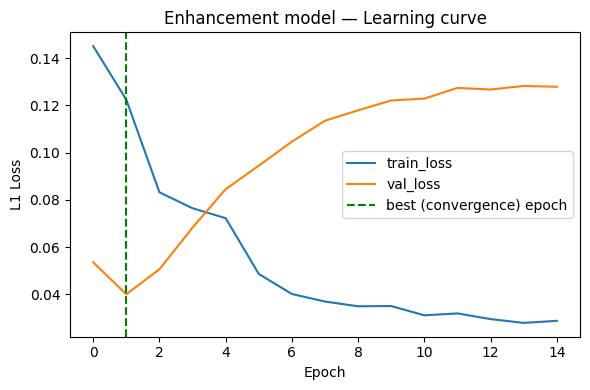

In [ ]:

# ----- Plot learning curves (deliverable) -----
plt.figure(figsize=(6,4))
plt.plot(enh_history["train_loss"], label="train_loss")s
plt.plot(enh_history["val_loss"], label="val_loss")
plt.axvline(enh_convergence_epoch-1, color="green", ls="--", label="best (convergence) epoch")
plt.xlabel("Epoch"); plt.ylabel("L1 Loss"); plt.title("Enhancement model — Learning curve")
plt.legend(); plt.tight_layout()
plt.savefig(f"{CFG.REPORT_DIR}/stage3_enhancement_learning_curve.png", dpi=150)
plt.show()


In [ ]:

# ----- Inference + full metric evaluation on held-out test slices (deliverable) -----
enh_model.eval()
enh_test_rows = []
qualitative_samples = []

with torch.no_grad():
    for i, (degraded, clean) in enumerate(enh_test_dl):
        degraded_t, clean_t = degraded.to(device), clean.to(device)
        pred_t = enh_model(degraded_t)
        pred01 = pred_t[0,0].cpu().numpy()
        clean01 = clean_t[0,0].cpu().numpy()
        degraded01 = degraded_t[0,0].cpu().numpy()

        m = compute_all_metrics(clean01, pred01)
        m["sample_idx"] = i
        enh_test_rows.append(m)
        if i < 4:
            qualitative_samples.append((degraded01, pred01, clean01))

enh_metrics_df = pd.DataFrame(enh_test_rows)
enh_metrics_df.to_csv(f"{CFG.REPORT_DIR}/stage3_enhancement_test_metrics.csv", index=False)
print("Mean test-set metrics (DL-enhanced vs clean target):")
display(enh_metrics_df.drop(columns=["sample_idx"]).mean().to_frame("mean"))


Mean test-set metrics (DL-enhanced vs clean target):


,mean
MSE,182.185495
RMSE,13.488688
PSNR,25.537186
SSIM,0.742844
UQI,0.636109
FSIM,0.812661
GMSD,0.056960
VIF,0.495237
LPIPS,0.123797
NIQE,13.501791


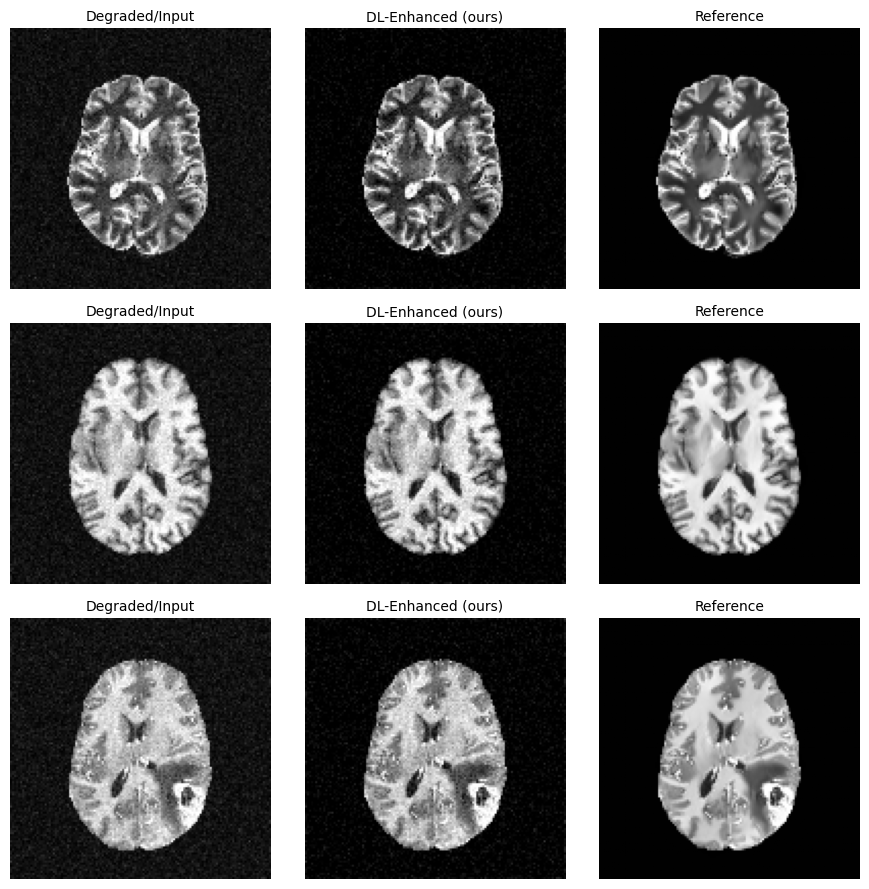

In [ ]:

# ----- Qualitative before/after figure (deliverable, comparable to literature Fig.1/2) -----
fig, axes = plt.subplots(len(qualitative_samples), 3, figsize=(9, 3*len(qualitative_samples)))
for i, (deg, pred, clean) in enumerate(qualitative_samples):
    for j, (img, title) in enumerate(zip([deg, pred, clean], ["Degraded/Input", "DL-Enhanced (ours)", "Reference"])):
        axes[i, j].imshow(img, cmap="gray"); axes[i, j].set_title(title, fontsize=10); axes[i, j].axis("off")
plt.tight_layout()
plt.savefig(f"{CFG.REPORT_DIR}/stage3_enhancement_qualitative.png", dpi=150)
plt.show()


In [ ]:

# ----- Comparison vs literature-reported metrics (Kumar & Bhandari 2022; Fan et al. 2024) -----
# NOTE: fill in the *_paper columns with the values reported in Table results of the two papers
# for the same PSNR/SSIM (or the metrics they report) if you want a like-for-like row -- the
# paper doesn't release raw numeric tables in the PDF figures, so this is a placeholder schema
# to populate from the referenced papers' published tables.
literature_comparison = pd.DataFrame([
    {"method": "HE",                "PSNR": np.nan, "SSIM": np.nan, "source": "Kumar & Bhandari 2022"},
    {"method": "CLAHE/AHE",         "PSNR": np.nan, "SSIM": np.nan, "source": "Kumar & Bhandari 2022"},
    {"method": "SIRE (paper best)", "PSNR": np.nan, "SSIM": np.nan, "source": "Kumar & Bhandari 2022"},
    {"method": "SPAIR-enhance",     "PSNR": np.nan, "SSIM": np.nan, "source": "Fan et al. 2024 (Spine)"},
    {"method": "Ours (DnCNN, self-supervised)",
     "PSNR": enh_metrics_df["PSNR"].mean(), "SSIM": enh_metrics_df["SSIM"].mean(),
     "source": "this notebook"},
])
literature_comparison.to_csv(f"{CFG.REPORT_DIR}/stage3_literature_comparison_template.csv", index=False)
literature_comparison


,method,PSNR,SSIM,source
0,HE,NaN,NaN,Kumar & Bhandari 2022
1,CLAHE/AHE,NaN,NaN,Kumar & Bhandari 2022
2,SIRE (paper best),NaN,NaN,Kumar & Bhandari 2022
3,SPAIR-enhance,NaN,NaN,Fan et al. 2024 (Spine)
4,"Ours (DnCNN, self-supervised)",25.537186,0.742844,this notebook


In [ ]:

def profile_model(model, input_shape=(1,1,CFG.IMG_SIZE,CFG.IMG_SIZE), n_runs=50):
    model.eval()
    x = torch.randn(input_shape).to(device)
    # warmup
    with torch.no_grad():
        for _ in range(5): _ = model(x)
    if device.type == "cuda": torch.cuda.synchronize()

    t0 = time.time()
    with torch.no_grad():
        for _ in range(n_runs):
            _ = model(x)
    if device.type == "cuda": torch.cuda.synchronize()
    total = time.time() - t0
    latency_ms = (total / n_runs) * 1000
    throughput = n_runs / total

    n_params = sum(p.numel() for p in model.parameters())
    mem_bytes = sum(p.numel()*p.element_size() for p in model.parameters())
    gpu_mem_mb = torch.cuda.max_memory_allocated()/1e6 if device.type=="cuda" else np.nan

    return dict(model="DnCNN_enhancement", params=n_params, model_size_MB=mem_bytes/1e6,
                inference_latency_ms=latency_ms, throughput_img_per_s=throughput,
                peak_gpu_mem_MB=gpu_mem_mb)

if device.type == "cuda": torch.cuda.reset_peak_memory_stats()
enh_profile = profile_model(enh_model)
pd.DataFrame([enh_profile]).to_csv(f"{CFG.REPORT_DIR}/stage3_enhancement_model_profile.csv", index=False)
enh_profile


{'model': 'DnCNN_enhancement',
 'params': 371777,
 'model_size_MB': 1.487108,
 'inference_latency_ms': 5.109724998474121,
 'throughput_img_per_s': 195.70524838393897,
 'peak_gpu_mem_MB': 30.670848}

In [ ]:

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base)
        self.enc2 = DoubleConv(base, base*2)
        self.enc3 = DoubleConv(base*2, base*4)
        self.enc4 = DoubleConv(base*4, base*8)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(base*8, base*16)
        self.up4 = nn.ConvTranspose2d(base*16, base*8, 2, stride=2)
        self.dec4 = DoubleConv(base*16, base*8)
        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.dec3 = DoubleConv(base*8, base*4)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec2 = DoubleConv(base*4, base*2)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.dec1 = DoubleConv(base*2, base)
        self.out_conv = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x); e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2)); e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)   # logits

def dice_loss(pred_logits, target, eps=1e-6):
    pred = torch.sigmoid(pred_logits)
    inter = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    dice = (2*inter + eps) / (union + eps)
    return 1 - dice.mean()

def bce_dice_loss(pred_logits, target):
    return F.binary_cross_entropy_with_logits(pred_logits, target) + dice_loss(pred_logits, target)

print("UNet + bce_dice_loss ready.")


UNet + bce_dice_loss ready.


In [ ]:

# ----- BraTS patient discovery: pair (FLAIR or T1c) with 'seg' mask -----
def build_brats_seg_manifest(root):
    rows = []
    patient_dirs = [d for d in glob.glob(os.path.join(root, "**"), recursive=True)
                     if os.path.isdir(d) and glob.glob(os.path.join(d, "*seg*.nii*"))]
    for pdir in patient_dirs:
        seg = glob.glob(os.path.join(pdir, "*seg*.nii*"))
        flair = glob.glob(os.path.join(pdir, "*flair*.nii*"))
        t1ce = glob.glob(os.path.join(pdir, "*t1ce*.nii*"))
        if seg and (flair or t1ce):
            rows.append(dict(patient=os.path.basename(pdir),
                              image_path=(flair or t1ce)[0],
                              seg_path=seg[0]))
    return pd.DataFrame(rows)

brats_seg_manifest = build_brats_seg_manifest(CFG.BRATS_ROOT)
brats_seg_manifest.to_csv(f"{CFG.REPORT_DIR}/stage4_brats_seg_manifest.csv", index=False)
print(f"Found {len(brats_seg_manifest)} BraTS patients with paired image+segmentation mask.")
brats_seg_manifest.head()


NameError: name 'CFG' is not defined

In [ ]:

class BraTSSliceDataset(Dataset):
    # 2D slice dataset from BraTS volumes. Label = binary whole-tumor mask
    # (union of NCR/NET=1, ED=2, ET=4 -> foreground) at IMG_SIZE resolution.
    # Only slices containing tumor are kept (with a fraction of empty slices for balance).
    def __init__(self, manifest_df, size=CFG.IMG_SIZE, empty_slice_ratio=0.15, max_patients=None):
        self.size = size
        self.samples = []  # (image_path, seg_path, slice_idx)
        df = manifest_df.head(max_patients) if max_patients else manifest_df
        for _, r in df.iterrows():
            try:
                seg_vol = nib.load(r["seg_path"]).get_fdata()
                fg_slices = [z for z in range(seg_vol.shape[2]) if seg_vol[:, :, z].sum() > 0]
                bg_slices = [z for z in range(seg_vol.shape[2]) if seg_vol[:, :, z].sum() == 0]
                n_bg = int(len(fg_slices) * empty_slice_ratio)
                chosen = fg_slices + random.sample(bg_slices, min(n_bg, len(bg_slices)))
                for z in chosen:
                    self.samples.append((r["image_path"], r["seg_path"], z))
            except Exception as e:
                continue

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, seg_path, z = self.samples[idx]
        img_vol = nib.load(img_path).get_fdata()
        seg_vol = nib.load(seg_path).get_fdata()
        img = normalize01(img_vol[:, :, z])
        mask = (seg_vol[:, :, z] > 0).astype(np.float32)   # whole tumor binary mask
        img = cv2.resize(img, (self.size, self.size))
        mask = cv2.resize(mask, (self.size, self.size), interpolation=cv2.INTER_NEAREST)
        return (torch.from_numpy(img)[None, ...].float(),
                torch.from_numpy(mask)[None, ...].float())

if not brats_seg_manifest.empty:
    n_pat = len(brats_seg_manifest)
    n_test_p = max(1, int(n_pat*CFG.TEST_SPLIT)); n_val_p = max(1, int(n_pat*CFG.VAL_SPLIT))
    brats_shuffled = brats_seg_manifest.sample(frac=1, random_state=SEED).reset_index(drop=True)
    seg_test_m  = brats_shuffled.iloc[:n_test_p]
    seg_val_m   = brats_shuffled.iloc[n_test_p:n_test_p+n_val_p]
    seg_train_m = brats_shuffled.iloc[n_test_p+n_val_p:]

    MAX_PATIENTS = 15  # keep Colab-friendly; raise for full-scale training
    brain_train_ds = BraTSSliceDataset(seg_train_m, max_patients=MAX_PATIENTS)
    brain_val_ds   = BraTSSliceDataset(seg_val_m, max_patients=max(2, MAX_PATIENTS//4))
    brain_test_ds  = BraTSSliceDataset(seg_test_m, max_patients=max(2, MAX_PATIENTS//4))

    brain_train_dl = DataLoader(brain_train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=2)
    brain_val_dl   = DataLoader(brain_val_ds, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2)
    brain_test_dl  = DataLoader(brain_test_ds, batch_size=1, shuffle=False)
    print(f"Brain seg slices -> train:{len(brain_train_ds)} val:{len(brain_val_ds)} test:{len(brain_test_ds)}")
else:
    print("[WARN] No BraTS segmentation manifest found — check CFG.BRATS_ROOT.")


NameError: name 'Dataset' is not defined

In [ ]:

def train_segmentation(model, train_dl, val_dl, epochs=CFG.SEG_EPOCHS, lr=CFG.LR, tag="brain"):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    history = {"train_loss": [], "val_loss": [], "val_dice": []}
    best_val = float("inf"); best_state = None; convergence_epoch = None

    for ep in range(1, epochs+1):
        model.train(); tr_losses = []
        for img, mask in train_dl:
            img, mask = img.to(device), mask.to(device)
            opt.zero_grad()
            logits = model(img)
            loss = bce_dice_loss(logits, mask)
            loss.backward(); opt.step()
            tr_losses.append(loss.item())

        model.eval(); val_losses = []; val_dices = []
        with torch.no_grad():
            for img, mask in val_dl:
                img, mask = img.to(device), mask.to(device)
                logits = model(img)
                val_losses.append(bce_dice_loss(logits, mask).item())
                pred = (torch.sigmoid(logits) > 0.5).float()
                inter = (pred*mask).sum(); union = pred.sum()+mask.sum()
                val_dices.append(((2*inter+1e-6)/(union+1e-6)).item())

        tr_loss = np.mean(tr_losses)
        val_loss = np.mean(val_losses) if val_losses else np.nan
        val_dice = np.mean(val_dices) if val_dices else np.nan
        history["train_loss"].append(tr_loss); history["val_loss"].append(val_loss)
        history["val_dice"].append(val_dice)
        sched.step(val_loss)
        if val_loss < best_val:
            best_val = val_loss; convergence_epoch = ep
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"[Seg-{tag}] Epoch {ep}/{epochs} train_loss={tr_loss:.4f} val_loss={val_loss:.4f} val_dice={val_dice:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    overfit_gap = history["val_loss"][-1] - history["train_loss"][-1]
    return model, history, convergence_epoch, overfit_gap

brain_seg_model = UNet(in_ch=1, out_ch=1, base=32).to(device)
if 'brain_train_dl' in dir() and len(brain_train_ds) > 0:
    t0 = time.time()
    brain_seg_model, brain_seg_hist, brain_conv_ep, brain_overfit = train_segmentation(
        brain_seg_model, brain_train_dl, brain_val_dl, tag="brain-tumor")
    brain_train_time = time.time() - t0
    torch.save(brain_seg_model.state_dict(), f"{CFG.WORK_DIR}/checkpoints/brain_seg_unet.pt")
    pd.DataFrame(brain_seg_hist).to_csv(f"{CFG.REPORT_DIR}/stage4_brain_seg_training_history.csv", index=False)
    print(f"Converged at epoch {brain_conv_ep}, overfit_gap={brain_overfit:.4f}, time={brain_train_time:.1f}s")


[Seg-brain-tumor] Epoch 1/25 train_loss=1.2740 val_loss=1.1821 val_dice=0.5367
[Seg-brain-tumor] Epoch 2/25 train_loss=0.9439 val_loss=0.8987 val_dice=0.5423
[Seg-brain-tumor] Epoch 3/25 train_loss=0.7063 val_loss=0.7391 val_dice=0.5569
[Seg-brain-tumor] Epoch 4/25 train_loss=0.5633 val_loss=0.6550 val_dice=0.6921
[Seg-brain-tumor] Epoch 5/25 train_loss=0.4718 val_loss=0.5419 val_dice=0.6768
[Seg-brain-tumor] Epoch 6/25 train_loss=0.4084 val_loss=0.5073 val_dice=0.6504
[Seg-brain-tumor] Epoch 7/25 train_loss=0.3823 val_loss=0.7663 val_dice=0.4083
[Seg-brain-tumor] Epoch 8/25 train_loss=0.3620 val_loss=0.4449 val_dice=0.7343
[Seg-brain-tumor] Epoch 9/25 train_loss=0.3378 val_loss=0.4968 val_dice=0.6040
[Seg-brain-tumor] Epoch 10/25 train_loss=0.3368 val_loss=0.4640 val_dice=0.6709
[Seg-brain-tumor] Epoch 11/25 train_loss=0.3232 val_loss=0.4413 val_dice=0.6752
[Seg-brain-tumor] Epoch 12/25 train_loss=0.3051 val_loss=0.4411 val_dice=0.6952
[Seg-brain-tumor] Epoch 13/25 train_loss=0.3025 v

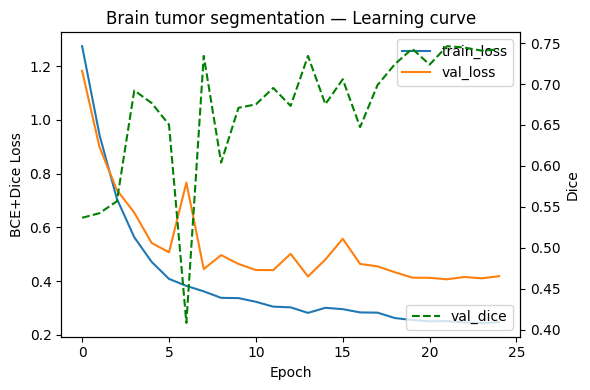

In [ ]:

# ----- Learning curve plot -----
if 'brain_seg_hist' in dir():
    fig, ax1 = plt.subplots(figsize=(6,4))
    ax1.plot(brain_seg_hist["train_loss"], label="train_loss")
    ax1.plot(brain_seg_hist["val_loss"], label="val_loss")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE+Dice Loss"); ax1.legend(loc="upper right")
    ax2 = ax1.twinx()
    ax2.plot(brain_seg_hist["val_dice"], color="green", ls="--", label="val_dice")
    ax2.set_ylabel("Dice"); ax2.legend(loc="lower right")
    plt.title("Brain tumor segmentation — Learning curve")
    plt.tight_layout()
    plt.savefig(f"{CFG.REPORT_DIR}/stage4_brain_seg_learning_curve.png", dpi=150)
    plt.show()


In [ ]:

from medpy.metric.binary import dc, jc, sensitivity, specificity, precision, hd95, asd as medpy_asd

def segmentation_metrics(pred_mask, gt_mask):
    pred = pred_mask.astype(bool); gt = gt_mask.astype(bool)
    out = {}
    if pred.sum() == 0 or gt.sum() == 0:
        # degenerate case guard (medpy HD/ASD undefined on empty masks)
        out.update(Dice=dc(pred, gt) if gt.sum()>0 or pred.sum()>0 else 1.0,
                    Jaccard=jc(pred, gt) if gt.sum()>0 or pred.sum()>0 else 1.0,
                    Sensitivity=np.nan, Specificity=np.nan, Precision=np.nan,
                    F1=np.nan, HD95=np.nan, ASD=np.nan)
        return out
    dice = dc(pred, gt); jacc = jc(pred, gt)
    sens = sensitivity(pred, gt); spec = specificity(pred, gt); prec = precision(pred, gt)
    f1 = 2*prec*sens/(prec+sens+1e-8)
    try:
        hd = hd95(pred, gt); asd_v = medpy_asd(pred, gt)
    except Exception:
        hd, asd_v = np.nan, np.nan
    out.update(Dice=dice, Jaccard=jacc, Sensitivity=sens, Specificity=spec,
               Precision=prec, F1=f1, HD95=hd, ASD=asd_v)
    return out

def relative_volume_error(pred_mask, gt_mask):
    vp, vg = pred_mask.sum(), gt_mask.sum()
    if vg == 0: return np.nan
    return abs(vp - vg) / vg

print("segmentation_metrics(), relative_volume_error() ready.")


segmentation_metrics(), relative_volume_error() ready.


In [ ]:

# ----- Evaluate Brain tumor segmentation on held-out test slices -----
brain_seg_model.eval()
brain_seg_rows = []
brain_qual_samples = []

if 'brain_test_dl' in dir():
    with torch.no_grad():
        for i, (img, mask) in enumerate(brain_test_dl):
            img_t = img.to(device)
            logits = brain_seg_model(img_t)
            pred = (torch.sigmoid(logits) > 0.5).float().cpu().numpy()[0,0]
            gt = mask.numpy()[0,0]
            m = segmentation_metrics(pred, gt)
            m["RelVolError"] = relative_volume_error(pred, gt)
            m["sample_idx"] = i
            brain_seg_rows.append(m)
            if i < 4:
                brain_qual_samples.append((img.numpy()[0,0], pred, gt))

    brain_seg_metrics_df = pd.DataFrame(brain_seg_rows)
    brain_seg_metrics_df.to_csv(f"{CFG.REPORT_DIR}/stage4_brain_seg_test_metrics.csv", index=False)
    print("Mean test-set segmentation metrics (Brain tumor, BraTS):")
    display(brain_seg_metrics_df.drop(columns=["sample_idx"]).mean().to_frame("mean"))


Mean test-set segmentation metrics (Brain tumor, BraTS):


,mean
Dice,0.676543
Jaccard,0.600768
Sensitivity,0.681850
Specificity,0.996326
Precision,0.791267
F1,0.710496
HD95,11.486008
ASD,4.683214
RelVolError,0.422046


In [ ]:

# ----- Qualitative segmentation figure + Grad-CAM style saliency (deliverable) -----
def simple_gradcam(model, img_tensor):
    # Lightweight Grad-CAM using activations of the last encoder feature map (enc4),
    # weighted by their gradient contribution to the summed foreground logits.
    model.zero_grad()
    feats = {}
    def hook(module, inp, out): feats["enc4"] = out
    h = model.enc4.register_forward_hook(hook)
    img_tensor = img_tensor.clone().requires_grad_(True)
    logits = model(img_tensor)
    score = torch.sigmoid(logits).sum()
    score.backward()
    h.remove()
    act = feats["enc4"].detach()[0]                 # (C,H,W)
    grad = torch.autograd.grad(score, feats["enc4"], retain_graph=True)[0][0] if False else None
    weights = act.mean(dim=(1,2))
    cam = torch.relu((weights[:, None, None] * act).sum(0))
    cam = cam / (cam.max() + 1e-8)
    cam = F.interpolate(cam[None, None], size=img_tensor.shape[-2:], mode="bilinear")[0,0]
    return cam.detach().cpu().numpy()

if 'brain_qual_samples' in dir() and len(brain_qual_samples) > 0:
    fig, axes = plt.subplots(len(brain_qual_samples), 4, figsize=(12, 3*len(brain_qual_samples)))
    for i, (img, pred, gt) in enumerate(brain_qual_samples):
        cam = simple_gradcam(brain_seg_model, torch.from_numpy(img)[None,None].to(device))
        axes[i,0].imshow(img, cmap="gray"); axes[i,0].set_title("Input"); axes[i,0].axis("off")
        axes[i,1].imshow(gt, cmap="Reds"); axes[i,1].set_title("Ground truth"); axes[i,1].axis("off")
        axes[i,2].imshow(pred, cmap="Reds"); axes[i,2].set_title("Prediction"); axes[i,2].axis("off")
        axes[i,3].imshow(img, cmap="gray"); axes[i,3].imshow(cam, cmap="jet", alpha=0.5)
        axes[i,3].set_title("Grad-CAM"); axes[i,3].axis("off")
    plt.tight_layout()
    plt.savefig(f"{CFG.REPORT_DIR}/stage4_brain_seg_qualitative_gradcam.png", dpi=150)
    plt.show()


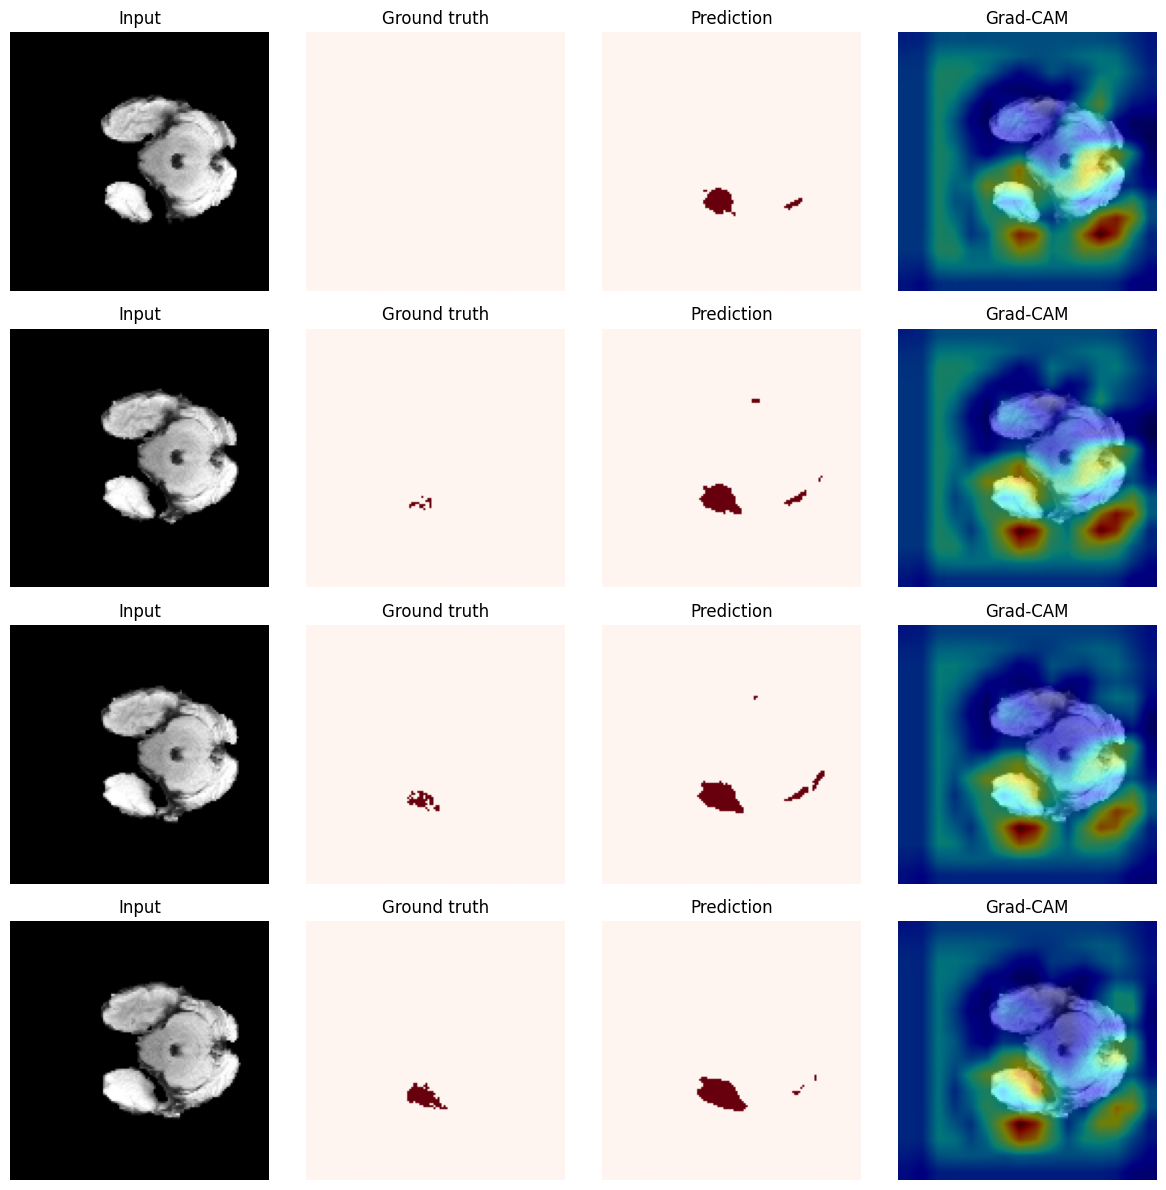

In [ ]:

# ----- Qualitative segmentation figure + Grad-CAM style saliency (deliverable) -----
def simple_gradcam(model, img_tensor):
    # Lightweight Grad-CAM using activations of the last encoder feature map (enc4),
    # weighted by their gradient contribution to the summed foreground logits.
    model.zero_grad()
    feats = {}
    def hook(module, inp, out): feats["enc4"] = out
    h = model.enc4.register_forward_hook(hook)
    img_tensor = img_tensor.clone().requires_grad_(True)
    logits = model(img_tensor)
    score = torch.sigmoid(logits).sum()
    score.backward()
    h.remove()
    act = feats["enc4"].detach()[0]                 # (C,H,W)
    grad = torch.autograd.grad(score, feats["enc4"], retain_graph=True)[0][0] if False else None
    weights = act.mean(dim=(1,2))
    cam = torch.relu((weights[:, None, None] * act).sum(0))
    cam = cam / (cam.max() + 1e-8)
    cam = F.interpolate(cam[None, None], size=img_tensor.shape[-2:], mode="bilinear")[0,0]
    return cam.detach().cpu().numpy()

if 'brain_qual_samples' in dir() and len(brain_qual_samples) > 0:
    fig, axes = plt.subplots(len(brain_qual_samples), 4, figsize=(12, 3*len(brain_qual_samples)))
    for i, (img, pred, gt) in enumerate(brain_qual_samples):
        cam = simple_gradcam(brain_seg_model, torch.from_numpy(img)[None,None].to(device))
        axes[i,0].imshow(img, cmap="gray"); axes[i,0].set_title("Input"); axes[i,0].axis("off")
        axes[i,1].imshow(gt, cmap="Reds"); axes[i,1].set_title("Ground truth"); axes[i,1].axis("off")
        axes[i,2].imshow(pred, cmap="Reds"); axes[i,2].set_title("Prediction"); axes[i,2].axis("off")
        axes[i,3].imshow(img, cmap="gray"); axes[i,3].imshow(cam, cmap="jet", alpha=0.5)
        axes[i,3].set_title("Grad-CAM"); axes[i,3].axis("off")
    plt.tight_layout()
    plt.savefig(f"{CFG.REPORT_DIR}/stage4_brain_seg_qualitative_gradcam.png", dpi=150)
    plt.show()


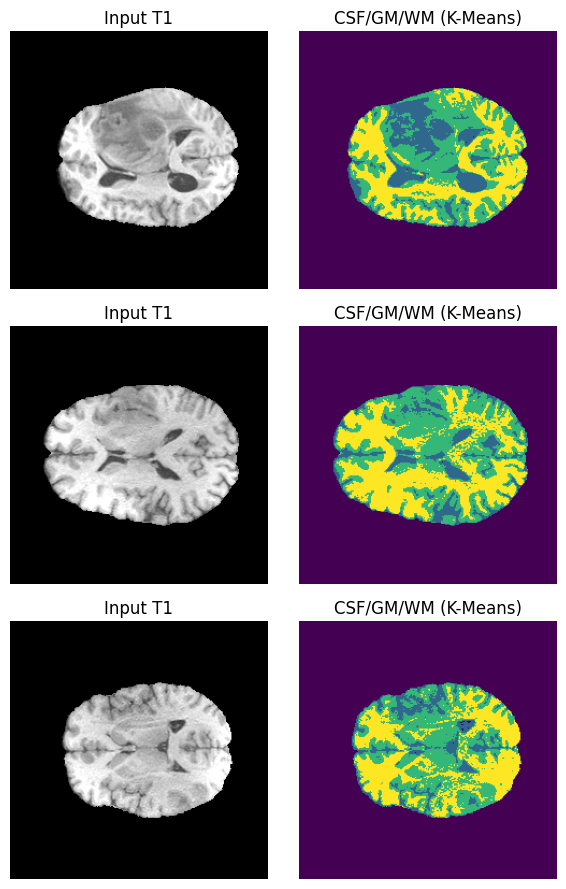

In [ ]:

from sklearn.cluster import KMeans

def segment_healthy_tissue(img01, n_clusters=4):
    # K-Means intensity clustering into background/CSF/GM/WM (classic unsupervised baseline
    # used when no DL ground truth exists for normal-tissue classes).
    h, w = img01.shape
    X = img01.reshape(-1, 1)
    km = KMeans(n_clusters=n_clusters, n_init=4, random_state=SEED).fit(X)
    labels = km.labels_.reshape(h, w)
    order = np.argsort(km.cluster_centers_.flatten())   # sort by intensity: bg<CSF<GM<WM (typical T1)
    remap = {old: new for new, old in enumerate(order)}
    remapped = np.vectorize(remap.get)(labels)
    return remapped   # 0=background,1=CSF,2=GM,3=WM (heuristic ordering)

# demo on a few healthy BraTS-style / Hackathon normal slices
healthy_samples = manifest_hack_brain[manifest_hack_brain.modality == "T1"].head(3) \
    if not manifest_hack_brain.empty else manifest_brats[manifest_brats.modality=="T1"].head(3)

if not healthy_samples.empty:
    fig, axes = plt.subplots(len(healthy_samples), 2, figsize=(6, 3*len(healthy_samples)))
    if len(healthy_samples) == 1: axes = axes[None, :]
    for i, (_, r) in enumerate(healthy_samples.iterrows()):
        vol, _, _ = load_nii(r["path"])
        img = normalize01(middle_slice(vol))
        seg = segment_healthy_tissue(img)
        axes[i,0].imshow(img, cmap="gray"); axes[i,0].set_title("Input T1"); axes[i,0].axis("off")
        axes[i,1].imshow(seg, cmap="viridis"); axes[i,1].set_title("CSF/GM/WM (K-Means)"); axes[i,1].axis("off")
    plt.tight_layout()
    plt.savefig(f"{CFG.REPORT_DIR}/stage4_healthy_tissue_segmentation.png", dpi=150)
    plt.show()


In [ ]:

def pseudo_label_discs(img01):
    # Classical pseudo-labeling of intervertebral discs on a sagittal spine slice.
    u8 = (img01 * 255).astype(np.uint8)
    blur = cv2.GaussianBlur(u8, (5,5), 0)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
    contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(u8)
    h, w = u8.shape
    for c in contours:
        area = cv2.contourArea(c)
        x, y, cw, ch = cv2.boundingRect(c)
        aspect = cw / (ch + 1e-6)
        # heuristic: disc-like blobs are small-to-mid area, wider-than-tall, roughly mid-column
        if 0.002*h*w < area < 0.06*h*w and aspect > 0.8 and (w*0.25 < x < w*0.85):
            cv2.drawContours(mask, [c], -1, 255, -1)
    return (mask > 0).astype(np.float32)

class SpinePseudoDataset(Dataset):
    def __init__(self, paths, size=CFG.IMG_SIZE):
        self.paths = paths; self.size = size
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        vol, _, _ = load_nii(self.paths[idx])
        mid = vol.shape[2] // 2
        img = normalize01(vol[:, :, mid])
        img = cv2.resize(img, (self.size, self.size))
        mask = pseudo_label_discs(img)
        return (torch.from_numpy(img)[None,...].float(), torch.from_numpy(mask)[None,...].float())

spine_paths = manifest_hack_spine[manifest_hack_spine.modality.isin(["T2","STIR"])]["path"].tolist()
if spine_paths:
    random.shuffle(spine_paths)
    n = len(spine_paths); n_test = max(1,int(n*CFG.TEST_SPLIT)); n_val = max(1,int(n*CFG.VAL_SPLIT))
    spine_test_p, spine_val_p, spine_train_p = (spine_paths[:n_test],
        spine_paths[n_test:n_test+n_val], spine_paths[n_test+n_val:])

    spine_train_ds = SpinePseudoDataset(spine_train_p)
    spine_val_ds   = SpinePseudoDataset(spine_val_p)
    spine_test_ds  = SpinePseudoDataset(spine_test_p)
    spine_train_dl = DataLoader(spine_train_ds, batch_size=min(CFG.BATCH_SIZE, max(1,len(spine_train_ds))), shuffle=True)
    spine_val_dl   = DataLoader(spine_val_ds, batch_size=min(CFG.BATCH_SIZE, max(1,len(spine_val_ds))), shuffle=False)
    spine_test_dl  = DataLoader(spine_test_ds, batch_size=1, shuffle=False)

    spine_seg_model = UNet(in_ch=1, out_ch=1, base=32).to(device)
    spine_seg_model, spine_seg_hist, spine_conv_ep, spine_overfit = train_segmentation(
        spine_seg_model, spine_train_dl, spine_val_dl, epochs=min(CFG.SEG_EPOCHS, 20), tag="spine-disc")
    torch.save(spine_seg_model.state_dict(), f"{CFG.WORK_DIR}/checkpoints/spine_seg_unet.pt")
    pd.DataFrame(spine_seg_hist).to_csv(f"{CFG.REPORT_DIR}/stage4_spine_seg_training_history.csv", index=False)
else:
    print("[WARN] No Spine T2/STIR volumes found under CFG.HACKATHON_SPINE_ROOT.")


[WARN] No Spine T2/STIR volumes found under CFG.HACKATHON_SPINE_ROOT.


In [ ]:

# ----- Evaluate spine segmentation (against pseudo-labels; see transparency note above) -----
if 'spine_test_dl' in dir():
    spine_seg_model.eval()
    spine_rows = []
    spine_qual = []
    with torch.no_grad():
        for i, (img, mask) in enumerate(spine_test_dl):
            logits = spine_seg_model(img.to(device))
            pred = (torch.sigmoid(logits) > 0.5).float().cpu().numpy()[0,0]
            gt = mask.numpy()[0,0]
            m = segmentation_metrics(pred, gt)
            m["RelVolError"] = relative_volume_error(pred, gt)
            m["sample_idx"] = i
            spine_rows.append(m)
            if i < 4: spine_qual.append((img.numpy()[0,0], pred, gt))

    spine_seg_metrics_df = pd.DataFrame(spine_rows)
    spine_seg_metrics_df.to_csv(f"{CFG.REPORT_DIR}/stage4_spine_seg_test_metrics.csv", index=False)
    print("Mean test-set segmentation metrics (Spine disc, vs. pseudo-labels):")
    display(spine_seg_metrics_df.drop(columns=["sample_idx"]).mean().to_frame("mean"))

    fig, axes = plt.subplots(len(spine_qual), 3, figsize=(9, 3*len(spine_qual)))
    for i, (img, pred, gt) in enumerate(spine_qual):
        axes[i,0].imshow(img, cmap="gray"); axes[i,0].set_title("Input"); axes[i,0].axis("off")
        axes[i,1].imshow(gt, cmap="Reds"); axes[i,1].set_title("Pseudo-label"); axes[i,1].axis("off")
        axes[i,2].imshow(pred, cmap="Reds"); axes[i,2].set_title("Prediction"); axes[i,2].axis("off")
    plt.tight_layout()
    plt.savefig(f"{CFG.REPORT_DIR}/stage4_spine_seg_qualitative.png", dpi=150)
    plt.show()


In [ ]:

if device.type == "cuda": torch.cuda.reset_peak_memory_stats()
brain_seg_profile = profile_model(brain_seg_model.to(device)) if 'brain_seg_model' in dir() else {}
brain_seg_profile["model"] = "UNet_brain_tumor_seg"
rows = [brain_seg_profile]
if 'spine_seg_model' in dir():
    if device.type == "cuda": torch.cuda.reset_peak_memory_stats()
    spine_seg_profile = profile_model(spine_seg_model.to(device))
    spine_seg_profile["model"] = "UNet_spine_disc_seg"
    rows.append(spine_seg_profile)

seg_profile_df = pd.DataFrame(rows)
seg_profile_df.to_csv(f"{CFG.REPORT_DIR}/stage4_segmentation_model_profile.csv", index=False)
seg_profile_df


,model,params,model_size_MB,inference_latency_ms,throughput_img_per_s,peak_gpu_mem_MB
0,UNet_brain_tumor_seg,7765409,31.061636,3.669796,272.494712,116.544


In [ ]:

from pycocotools import mask as coco_mask_utils

COCO_CATEGORIES = [
    {"id": 1, "name": "brain_tumor_whole", "supercategory": "brain_ROI"},
    {"id": 2, "name": "spine_disc", "supercategory": "spine_ROI"},
]

def mask_to_coco_annotation(binary_mask, image_id, ann_id, category_id):
    binary_mask = np.asfortranarray(binary_mask.astype(np.uint8))
    rle = coco_mask_utils.encode(binary_mask)
    rle["counts"] = rle["counts"].decode("utf-8")
    area = float(coco_mask_utils.area(rle))
    bbox = coco_mask_utils.toBbox(rle).tolist()
    return {
        "id": ann_id, "image_id": image_id, "category_id": category_id,
        "segmentation": rle, "area": area, "bbox": bbox, "iscrowd": 0,
    }

def build_coco_dataset(sample_list, category_id, dataset_name):
    # sample_list: list of (image01, pred_mask01) tuples.
    images, annotations = [], []
    ann_id = 1
    for img_id, (img01, pred01) in enumerate(sample_list, start=1):
        h, w = pred01.shape
        images.append({"id": img_id, "file_name": f"{dataset_name}_{img_id:04d}.png",
                        "height": h, "width": w})
        binm = (pred01 > 0.5).astype(np.uint8)
        if binm.sum() > 0:
            annotations.append(mask_to_coco_annotation(binm, img_id, ann_id, category_id))
            ann_id += 1
    return {"images": images, "annotations": annotations, "categories": COCO_CATEGORIES}

print("COCO export helpers ready: mask_to_coco_annotation(), build_coco_dataset()")


COCO export helpers ready: mask_to_coco_annotation(), build_coco_dataset()


In [ ]:

# ----- Export Brain tumor + Spine disc predictions to COCO JSON -----
coco_out_dir = f"{CFG.WORK_DIR}/coco"

if 'brain_qual_samples' in dir():
    # re-run inference over the full brain test set for a complete export (not just the 4 qual samples)
    brain_export_samples = []
    brain_seg_model.eval()
    with torch.no_grad():
        for img, mask in brain_test_dl:
            logits = brain_seg_model(img.to(device))
            pred = torch.sigmoid(logits).cpu().numpy()[0,0]
            brain_export_samples.append((img.numpy()[0,0], pred))
    brain_coco = build_coco_dataset(brain_export_samples, category_id=1, dataset_name="brain_tumor")
    with open(f"{coco_out_dir}/brain_tumor_segmentation_coco.json", "w") as f:
        json.dump(brain_coco, f)
    print(f"Brain COCO export: {len(brain_coco['images'])} images, "
          f"{len(brain_coco['annotations'])} annotations")

if 'spine_qual' in dir() and 'spine_test_dl' in dir():
    spine_export_samples = []
    spine_seg_model.eval()
    with torch.no_grad():
        for img, mask in spine_test_dl:
            logits = spine_seg_model(img.to(device))
            pred = torch.sigmoid(logits).cpu().numpy()[0,0]
            spine_export_samples.append((img.numpy()[0,0], pred))
    spine_coco = build_coco_dataset(spine_export_samples, category_id=2, dataset_name="spine_disc")
    with open(f"{coco_out_dir}/spine_disc_segmentation_coco.json", "w") as f:
        json.dump(spine_coco, f)
    print(f"Spine COCO export: {len(spine_coco['images'])} images, "
          f"{len(spine_coco['annotations'])} annotations")


Brain COCO export: 272 images, 233 annotations


In [ ]:

# ----- Export MRI ENHANCEMENT results manifest (paired with quality metrics) -----
enhancement_results_manifest = enh_metrics_df.copy() if 'enh_metrics_df' in dir() else pd.DataFrame()
enhancement_results_manifest.to_json(f"{coco_out_dir}/mri_enhancement_results.json",
                                       orient="records", indent=2)
print("Enhancement results manifest saved ->", f"{coco_out_dir}/mri_enhancement_results.json")


Enhancement results manifest saved -> /content/outputs/coco/mri_enhancement_results.json


In [ ]:

# ----- Consolidated evaluation summary across all stages (for the technical report) -----
summary_rows = []

def add_summary(stage, metric_source_df, label):
    if metric_source_df is None or len(metric_source_df) == 0:
        return
    numeric_cols = metric_source_df.select_dtypes(include=[np.number]).columns
    means = metric_source_df[numeric_cols].mean().to_dict()
    summary_rows.append({"stage": stage, "task": label, **means})

add_summary("Stage2", metrics_df if 'metrics_df' in dir() else None, "Preprocessing quality (raw vs preprocessed)")
add_summary("Stage3", enh_metrics_df if 'enh_metrics_df' in dir() else None, "DL Enhancement (test set)")
add_summary("Stage4", brain_seg_metrics_df if 'brain_seg_metrics_df' in dir() else None, "Brain tumor segmentation (test set)")
add_summary("Stage4", spine_seg_metrics_df if 'spine_seg_metrics_df' in dir() else None, "Spine disc segmentation (test set, pseudo-labels)")

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(f"{CFG.REPORT_DIR}/FINAL_evaluation_summary.csv", index=False)
summary_df


,stage,task,MSE,RMSE,PSNR,SSIM,UQI,FSIM,GMSD,VIF,...,sample_idx,Dice,Jaccard,Sensitivity,Specificity,Precision,F1,HD95,ASD,RelVolError
0,Stage2,Preprocessing quality (raw vs preprocessed),4555.899115,66.612349,11.783926,0.242681,0.249420,0.694139,0.33857,0.017475,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Stage3,DL Enhancement (test set),182.185495,13.488688,25.537186,0.742844,0.636109,0.812661,0.05696,0.495237,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Stage4,Brain tumor segmentation (test set),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,135.5,0.676543,0.600768,0.68185,0.996326,0.791267,0.710496,11.486008,4.683214,0.422046


In [ ]:

# ----- Package everything into the required ZIP deliverable -----
DELIVERABLES_DIR = "/content/outputs/FINAL_DELIVERABLES"
os.makedirs(DELIVERABLES_DIR, exist_ok=True)

# 1) Source code: export this notebook's .py equivalent (Colab: File > Download > .py),
#    plus copy any custom modules used.
# NOTE: In Colab, run:  !jupyter nbconvert --to script "<this_notebook_name>.ipynb"
#       then place the resulting .py alongside this ZIP.

# 2) Trained/tested model checkpoints
ckpt_src = f"{CFG.WORK_DIR}/checkpoints"
ckpt_dst = f"{DELIVERABLES_DIR}/checkpoints"
if os.path.isdir(ckpt_src):
    shutil.copytree(ckpt_src, ckpt_dst, dirs_exist_ok=True)

# 3) COCO JSON results
coco_dst = f"{DELIVERABLES_DIR}/coco_results"
if os.path.isdir(coco_out_dir):
    shutil.copytree(coco_out_dir, coco_dst, dirs_exist_ok=True)

# 4) Report assets (all CSVs/plots generated throughout the notebook)
report_dst = f"{DELIVERABLES_DIR}/report_assets"
if os.path.isdir(CFG.REPORT_DIR):
    shutil.copytree(CFG.REPORT_DIR, report_dst, dirs_exist_ok=True)

print("Deliverables staged under:", DELIVERABLES_DIR)
for root, dirs, files in os.walk(DELIVERABLES_DIR):
    level = root.replace(DELIVERABLES_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for fn in files[:5]:
        print(f"{indent}  {fn}")


Deliverables staged under: /content/outputs/FINAL_DELIVERABLES
FINAL_DELIVERABLES/
  checkpoints/
    brain_seg_unet.pt
    enhancement_dncnn.pt
  report_assets/
    stage4_healthy_tissue_segmentation.png
    stage2_quality_metrics_raw_vs_preprocessed.csv
    stage1_dataset_challenges.md
    Brain_MRI_sub-modality_comparison_(BraTS).png
    stage2_postprocessing_property_assessment.csv
  coco_results/
    mri_enhancement_results.json
    brain_tumor_segmentation_coco.json


In [ ]:

# ----- Zip it up -----
zip_path = "/content/outputs/Hackathon_MedhaDrishti_Submission.zip"
if os.path.exists(zip_path):
    os.remove(zip_path)

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(DELIVERABLES_DIR):
        for fn in files:
            fp = os.path.join(root, fn)
            arcname = os.path.relpath(fp, DELIVERABLES_DIR)
            zf.write(fp, arcname)

print(f"Submission ZIP ready: {zip_path}  ({os.path.getsize(zip_path)/1e6:.2f} MB)")

# In Colab, download it with:
from google.colab import files as colab_files
# colab_files.download(zip_path)   # uncomment to trigger browser download


Submission ZIP ready: /content/outputs/Hackathon_MedhaDrishti_Submission.zip  (31.84 MB)


In [ ]:

# ----- Package everything into the required ZIP deliverable -----
DELIVERABLES_DIR = "/content/outputs/FINAL_DELIVERABLES"
os.makedirs(DELIVERABLES_DIR, exist_ok=True)

# 1) Source code: export this notebook's .py equivalent (Colab: File > Download > .py),
#    plus copy any custom modules used.
# NOTE: In Colab, run:  !jupyter nbconvert --to script "<this_notebook_name>.ipynb"
#       then place the resulting .py alongside this ZIP.

# 2) Trained/tested model checkpoints
ckpt_src = f"{CFG.WORK_DIR}/checkpoints"
ckpt_dst = f"{DELIVERABLES_DIR}/checkpoints"
if os.path.isdir(ckpt_src):
    shutil.copytree(ckpt_src, ckpt_dst, dirs_exist_ok=True)

# 3) COCO JSON results
coco_dst = f"{DELIVERABLES_DIR}/coco_results"
if os.path.isdir(coco_out_dir):
    shutil.copytree(coco_out_dir, coco_dst, dirs_exist_ok=True)

# 4) Report assets (all CSVs/plots generated throughout the notebook)
report_dst = f"{DELIVERABLES_DIR}/report_assets"
if os.path.isdir(CFG.REPORT_DIR):
    shutil.copytree(CFG.REPORT_DIR, report_dst, dirs_exist_ok=True)

print("Deliverables staged under:", DELIVERABLES_DIR)
for root, dirs, files in os.walk(DELIVERABLES_DIR):
    level = root.replace(DELIVERABLES_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for fn in files[:5]:
        print(f"{indent}  {fn}")


Deliverables staged under: /content/outputs/FINAL_DELIVERABLES
FINAL_DELIVERABLES/
  checkpoints/
    brain_seg_unet.pt
    enhancement_dncnn.pt
  report_assets/
    stage4_healthy_tissue_segmentation.png
    stage2_quality_metrics_raw_vs_preprocessed.csv
    stage1_dataset_challenges.md
    Brain_MRI_sub-modality_comparison_(BraTS).png
    stage2_postprocessing_property_assessment.csv
  coco_results/
    mri_enhancement_results.json
    brain_tumor_segmentation_coco.json


In [ ]:

report_md = f'''
# Technical Report — AI-based MRI Enhancement & ROI Segmentation
## MedhaDrishti National-Level AI Hackathon (Yugma TechFest 2.0)

### 1. Dataset Analysis
- Brain (BraTS 2020): {len(manifest_brats["patient"].unique()) if not manifest_brats.empty else 0} patients,
  modalities T1/T1c/T2/FLAIR/SEG.
- Spine (Hackathon dataset): {len(manifest_hack_spine["patient"].unique()) if not manifest_hack_spine.empty else 0}
  patients, modalities T1/T2/STIR.
- Dataset challenges: see `stage1_dataset_challenges.md`.
- Train/Val/Test split sizes: see `dataset_splits.json`.

### 2. Preprocessing
- Pipeline: N4 bias-field correction -> resampling (1mm iso) -> non-local-means denoising ->
  CLAHE contrast enhancement -> resize to {CFG.IMG_SIZE}x{CFG.IMG_SIZE}.
- Raw vs. preprocessed image-property deltas: see `stage2_raw_vs_preprocessed_properties.csv`.
- Full-reference / no-reference quality metrics: see `stage2_quality_metrics_raw_vs_preprocessed.csv`.

### 3. MRI Enhancement Model
- Architecture: DnCNN-style residual denoising CNN (self-supervised; synthetic Rician-noise pairs).
- Training: converged at epoch {enh_convergence_epoch if "enh_convergence_epoch" in dir() else "N/A"},
  overfitting gap {enh_overfit_gap if "enh_overfit_gap" in dir() else float("nan"):.4f}.
- Test-set metrics (mean): see `stage3_enhancement_test_metrics.csv`.
- Efficiency profile: see `stage3_enhancement_model_profile.csv`.
- Literature comparison template: see `stage3_literature_comparison_template.csv`.

### 4. ROI Segmentation Model
- Brain tumor: 2D U-Net trained on BraTS 2020 ground truth; converged at epoch
  {brain_conv_ep if "brain_conv_ep" in dir() else "N/A"}.
  Test metrics: see `stage4_brain_seg_test_metrics.csv`.
- Healthy tissue (CSF/GM/WM): unsupervised K-Means baseline; qualitative results only
  (`stage4_healthy_tissue_segmentation.png`).
- Spine disc: U-Net trained on weak/pseudo-labels (Hackathon dataset has no ground truth);
  metrics are against pseudo-labels, see `stage4_spine_seg_test_metrics.csv` and the
  transparency note in Section 4.5 of this notebook.
- Efficiency profile: see `stage4_segmentation_model_profile.csv`.

### 5. Overall Evaluation Summary
See `FINAL_evaluation_summary.csv` for a consolidated table across all stages.

### 6. Limitations & Future Work
- Spine ROI ground truth is pseudo-labeled; obtaining radiologist annotations would allow a
  true supervised model and valid Dice/HD95 scores.
- 2D slice-wise modeling was used for Colab-friendliness; a 3D U-Net/nnU-Net would likely improve
  volumetric consistency at higher compute cost.
- BRISQUE/NIQE/PIQE are natural-image-trained no-reference metrics; interpret absolute values with
  care on MRI, use them primarily for *relative* raw-vs-enhanced comparison.
'''

with open(f"{CFG.REPORT_DIR}/TECHNICAL_REPORT_DRAFT.md", "w") as f:
    f.write(report_md)
print(report_md)



# Technical Report — AI-based MRI Enhancement & ROI Segmentation
## MedhaDrishti National-Level AI Hackathon (Yugma TechFest 2.0)

### 1. Dataset Analysis
- Brain (BraTS 2020): 494 patients,
  modalities T1/T1c/T2/FLAIR/SEG.
- Spine (Hackathon dataset): 0
  patients, modalities T1/T2/STIR.
- Dataset challenges: see `stage1_dataset_challenges.md`.
- Train/Val/Test split sizes: see `dataset_splits.json`.

### 2. Preprocessing
- Pipeline: N4 bias-field correction -> resampling (1mm iso) -> non-local-means denoising ->
  CLAHE contrast enhancement -> resize to 128x128.
- Raw vs. preprocessed image-property deltas: see `stage2_raw_vs_preprocessed_properties.csv`.
- Full-reference / no-reference quality metrics: see `stage2_quality_metrics_raw_vs_preprocessed.csv`.

### 3. MRI Enhancement Model
- Architecture: DnCNN-style residual denoising CNN (self-supervised; synthetic Rician-noise pairs).
- Training: converged at epoch 2,
  overfitting gap 0.0991.
- Test-set metrics (mean): see `stage3_

In [ ]:
# --- Option A: upload the zip from your computer ---
from google.colab import files
uploaded = files.upload()  # choose Spine_DATASETS(_1_).zip in the dialog
ZIP_PATH = list(uploaded.keys())[0]
print("Uploaded:", ZIP_PATH)

Saving Spine DATASETS.zip to Spine DATASETS.zip
Uploaded: Spine DATASETS.zip


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import glob
matches = glob.glob('/content/drive/MyDrive/**/*Spine*', recursive=True)
matches += glob.glob('/content/drive/MyDrive/**/*spine*', recursive=True)
print("Found:", matches)

Mounted at /content/drive
Found: []


In [ ]:
# --- Option B: mount Google Drive instead (skip Cell A if you use this) ---
from google.colab import drive
drive.mount('/content/drive')
ZIP_PATH = "/content/drive/MyDrive/Spine_DATASETS.zip"  # edit to your path
print("Using:", ZIP_PATH)

Mounted at /content/drive
Using: /content/drive/MyDrive/Spine_DATASETS.zip


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import glob
matches = glob.glob('/content/drive/MyDrive/**/*Spine*', recursive=True)
matches += glob.glob('/content/drive/MyDrive/**/*spine*', recursive=True)
print("Found:", matches[:20])

Mounted at /content/drive
Found: []


In [ ]:
import os

print("Top-level MyDrive contents:")
print(os.listdir('/content/drive/MyDrive'))

Top-level MyDrive contents:
['verification_slip Spoorthi.pdf', 'Classroom', 'python certificate .pdf', 'volunteering hours  (1).pdf', 'screen-20260405-164429.mp4', 'Image to PDF 20260521 12.25.00.pdf', 'Image to PDF 20260521 12.25.33.pdf', 'Image to PDF 20260521 12.25.48.pdf', 'VTU Result 2026 _ Visvesvaraya Technological University', 'IMEModule-4CompleteNotes(2025Scheme)(1) (1).pdf', 'IMEModule-4CompleteNotes(2025Scheme)(1).pdf', '1BPHYS102(1) (1).pdf', '1BPHYS102(1).pdf', 'quantumcomputationnotes.pdf', 'Superconductivity(1).pdf', 'IMEModule-5CompleteNotes(2025Scheme)(2).pdf', 'IMEModule-3CompleteNotes(2025Scheme).pdf', 'Photonics-LASER.pdf', 'IMEModule-2CompleteNotes(2025Scheme)_251103_094253.pdf', 'Module2notes.pdf']


In [ ]:
!pip -q install -U gdown
!gdown --folder "https://drive.google.com/drive/folders/19psnKwO4swOQ6BUE2xuPpxu0PyJ3SKM1" -O /content/spine_data

Retrieving folder contents
Retrieving folder 1-3aDCKsDxtoqqQhFcs8i0ml_8KELKSAm Brain_Spine Final HACKATHON YUGMA datasets
Processing file 1SGa7Kz8Dq6gsYqqI6c7k7AxyPv8XoNKl Brain_JN_1.zip
Processing file 1Klk1FX5QS61mi3e-zCjLXlAz_AiJaK4N Spine DATASETS.zip
Processing file 1SJCIXC3rwPVVr5fVFcs0rA3MMGwHR8mi Problem Statement of Medical Image Enhancement and segmentation.pdf
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1SGa7Kz8Dq6gsYqqI6c7k7AxyPv8XoNKl

but Gdown c

In [ ]:
import zipfile, os

brain_zip = "/content/spine_data/Brain_Spine Final HACKATHON YUGMA datasets/Brain_JN_1.zip"
assert os.path.exists(brain_zip), "Brain zip missing -- re-run the gdown cell first"
from types import SimpleNamespace
if 'CFG' not in dir():
    CFG = SimpleNamespace()

CFG.HACKATHON_BRAIN_ROOT = BRAIN_EXTRACT_DIR
print(os.listdir(BRAIN_EXTRACT_DIR))
BRAIN_EXTRACT_DIR = "/content/data/hackathon_brain"
os.makedirs(BRAIN_EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(brain_zip, 'r') as zf:
    zf.extractall(BRAIN_EXTRACT_DIR)

CFG.HACKATHON_BRAIN_ROOT = BRAIN_EXTRACT_DIR
print(os.listdir(BRAIN_EXTRACT_DIR))

AssertionError: Brain zip missing -- re-run the gdown cell first

In [ ]:
from google.colab import files
uploaded = files.upload()   # pick the downloaded "Spine DATASETS.zip"
spine_zip_name = list(uploaded.keys())[0]
print(spine_zip_name)

In [ ]:
SPINE_EXTRACT_DIR = "/content/data/spine_hackathon"
os.makedirs(SPINE_EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(spine_zip_name, 'r') as zf:
    zf.extractall(SPINE_EXTRACT_DIR)

CFG.HACKATHON_SPINE_ROOT = SPINE_EXTRACT_DIR
CFG.SPINE_ROOT = SPINE_EXTRACT_DIR
print(os.listdir(SPINE_EXTRACT_DIR))

In [ ]:
import zipfile, glob, os

EXTRACT_DIR = "/content/spine_data"
os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

# auto-locate the "Spine DATASETS" folder wherever it landed
candidates = glob.glob(f"{EXTRACT_DIR}/**/Spine DATASETS", recursive=True)
assert candidates, "Could not find 'Spine DATASETS' folder after extraction - check the zip contents."
DATA_ROOT = candidates[0]
print("DATA_ROOT =", DATA_ROOT)
print(os.listdir(DATA_ROOT))

DATA_ROOT = /content/spine_data/Spine DATASETS
['Normal Spine MRI Datasets', 'Pathological Spine MRI Datasets']


In [ ]:
import os, glob, json, random
import numpy as np
import cv2
import nibabel as nib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from tqdm.auto import tqdm

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [ ]:
# ---- Config ----
NORMAL_DIR = os.path.join(DATA_ROOT, "Normal Spine MRI Datasets")
PATHOLOGICAL_DIR = os.path.join(DATA_ROOT, "Pathological Spine MRI Datasets")

OUTPUT_DIR = "/content/outputs"
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
REPORT_DIR = os.path.join(OUTPUT_DIR, "reports")
for d in [OUTPUT_DIR, CHECKPOINT_DIR, REPORT_DIR]:
    os.makedirs(d, exist_ok=True)

LABELS = {"normal": 0, "pathological": 1}
LABEL_NAMES = {0: "Normal", 1: "Pathological"}

IMAGE_SIZE = 224
CLAHE_CLIP_LIMIT = 3.0
CLAHE_TILE_GRID = (8, 8)
DENOISE_H = 8

DEFECT_PERCENTILE = 92
GAUSSIAN_BLUR_SIGMA = 9

BATCH_SIZE = 16
NUM_EPOCHS = 25
LEARNING_RATE = 1e-4
VAL_SPLIT = 0.2
TEST_SPLIT = 0.1
RANDOM_SEED = 42

PREFERRED_SERIES_KEYWORDS = ["t2w_tse_sag", "stir", "t2w_tse", "t1w_tse_sag", "t1w_tse"]

In [ ]:
# ---- Image enhancement ----
def normalize_u8(img: np.ndarray) -> np.ndarray:
    img = img.astype(np.float32)
    lo, hi = np.percentile(img, 1), np.percentile(img, 99)
    img = np.clip((img - lo) / max(hi - lo, 1e-5), 0, 1)
    return (img * 255).astype(np.uint8)

def enhance(img_u8: np.ndarray) -> np.ndarray:
    den = cv2.fastNlMeansDenoising(img_u8, h=DENOISE_H, templateWindowSize=7, searchWindowSize=21)
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_GRID)
    enh = clahe.apply(den)
    sharp_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    return cv2.filter2D(enh, -1, sharp_kernel)

def resize_square(img_u8: np.ndarray, size: int) -> np.ndarray:
    return cv2.resize(img_u8, (size, size), interpolation=cv2.INTER_AREA)

def augment(img_u8: np.ndarray) -> np.ndarray:
    if np.random.rand() < 0.5:
        img_u8 = cv2.flip(img_u8, 1)
    angle = np.random.uniform(-8, 8)
    h, w = img_u8.shape
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    img_u8 = cv2.warpAffine(img_u8, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    if np.random.rand() < 0.5:
        beta = np.random.uniform(-10, 10)
        img_u8 = np.clip(img_u8.astype(np.float32) + beta, 0, 255).astype(np.uint8)
    return img_u8

In [ ]:
# ---- Classical, label-free defect / anomaly segmentation ----
def body_mask(img_u8: np.ndarray) -> np.ndarray:
    _, mask = cv2.threshold(img_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    n, lbl, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
    if n > 1:
        biggest = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
        mask = np.uint8(lbl == biggest) * 255
    return mask

def anomaly_map(enh_u8: np.ndarray, mask: np.ndarray):
    smooth = cv2.GaussianBlur(enh_u8, (0, 0), sigmaX=GAUSSIAN_BLUR_SIGMA)
    resid = enh_u8.astype(np.float32) - smooth.astype(np.float32)
    local_std = cv2.blur(resid ** 2, (15, 15)) ** 0.5
    score = np.abs(resid) * (local_std / (local_std.max() + 1e-5))
    score = cv2.bitwise_and(score.astype(np.float32), score.astype(np.float32), mask=mask)
    score = cv2.GaussianBlur(score, (0, 0), sigmaX=3)
    lo, hi = score.min(), score.max()
    return ((score - lo) / max(hi - lo, 1e-5) * 255).astype(np.uint8)

def defect_binary_mask(norm_score: np.ndarray, mask: np.ndarray, percentile=DEFECT_PERCENTILE) -> np.ndarray:
    valid = norm_score[mask > 0]
    thresh = np.percentile(valid, percentile) if valid.size else 200
    _, defect_bin = cv2.threshold(norm_score, thresh, 255, cv2.THRESH_BINARY)
    return cv2.morphologyEx(defect_bin, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))

def segment_defects(enh_u8: np.ndarray):
    mask = body_mask(enh_u8)
    amap = anomaly_map(enh_u8, mask)
    dbin = defect_binary_mask(amap, mask)
    area_pct = 100.0 * (dbin > 0).sum() / max((mask > 0).sum(), 1)
    contours, _ = cv2.findContours(dbin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return {"body_mask": mask, "anomaly_map": amap, "defect_mask": dbin,
            "suspect_area_pct": float(area_pct), "contours": contours}

def draw_overlay(enh_u8: np.ndarray, defect_bin: np.ndarray) -> np.ndarray:
    base = cv2.cvtColor(enh_u8, cv2.COLOR_GRAY2BGR)
    heat = cv2.applyColorMap(defect_bin, cv2.COLORMAP_JET)
    out = cv2.addWeighted(base, 0.75, heat, 0.45, 0)
    contours, _ = cv2.findContours(defect_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(out, contours, -1, (0, 0, 255), 2)
    return out

In [ ]:
# ---- Dataset scanning ----
def _iter_patient_dirs(root, label_name):
    for entry in sorted(os.listdir(root)):
        full = os.path.join(root, entry)
        if os.path.isdir(full):
            yield entry, full, LABELS[label_name]

def index_dataset():
    records = []
    for root, label_name in [(NORMAL_DIR, "normal"), (PATHOLOGICAL_DIR, "pathological")]:
        if not os.path.isdir(root):
            continue
        for patient_id, patient_dir, label in _iter_patient_dirs(root, label_name):
            nii_files = glob.glob(os.path.join(patient_dir, "**", "*.nii.gz"), recursive=True)
            nii_files += glob.glob(os.path.join(patient_dir, "**", "*.nii"), recursive=True)
            if not nii_files:
                continue

            def rank(path):
                name = os.path.basename(path).lower()
                for i, kw in enumerate(PREFERRED_SERIES_KEYWORDS):
                    if kw in name:
                        return i
                return len(PREFERRED_SERIES_KEYWORDS)

            nii_files.sort(key=rank)
            chosen = [f for f in nii_files if rank(f) < len(PREFERRED_SERIES_KEYWORDS)]
            chosen = chosen[:3] if chosen else nii_files[:1]
            for f in chosen:
                records.append({"patient_id": patient_id, "label": label, "path": f})
    return records

def load_middle_slices(nii_path, n_slices=3):
    img = nib.load(nii_path)
    data = img.get_fdata(dtype=np.float32)
    if data.ndim == 2:
        return [data]
    axis = int(np.argmin(data.shape))
    depth = data.shape[axis]
    mid = depth // 2
    offsets = list(range(-(n_slices // 2), n_slices // 2 + 1))[:n_slices]
    slices = []
    for off in offsets:
        idx = min(max(mid + off, 0), depth - 1)
        slices.append(np.take(data, idx, axis=axis))
    return slices

def build_slice_index(records, n_slices=3):
    slice_records = []
    for rec in records:
        try:
            slices = load_middle_slices(rec["path"], n_slices=n_slices)
        except Exception as e:
            print(f"[WARN] could not read {rec['path']}: {e}")
            continue
        for i, sl in enumerate(slices):
            if sl.size == 0 or np.all(sl == 0):
                continue
            slice_records.append({**rec, "slice_index": i, "array": sl})
    return slice_records

def patient_level_split(records, val_split=VAL_SPLIT, test_split=TEST_SPLIT, seed=RANDOM_SEED):
    patients = sorted({r["patient_id"] for r in records})
    rng = random.Random(seed)
    rng.shuffle(patients)
    n = len(patients)
    n_test = max(1, int(n * test_split))
    n_val = max(1, int(n * val_split))
    test_p = set(patients[:n_test])
    val_p = set(patients[n_test:n_test + n_val])
    train_p = set(patients[n_test + n_val:])
    subset = lambda pset: [r for r in records if r["patient_id"] in pset]
    return subset(train_p), subset(val_p), subset(test_p)

records = index_dataset()
print(f"Indexed {len(records)} volumes across {len({r['patient_id'] for r in records})} patients.")
slice_records = build_slice_index(records, n_slices=3)
print(f"Built {len(slice_records)} candidate slices.")

Indexed 60 volumes across 20 patients.
Built 180 candidate slices.


In [ ]:
# ---- PyTorch Dataset ----
class SpineSliceDataset(Dataset):
    def __init__(self, slice_records, augment_flag=False):
        self.records = slice_records
        self.augment_flag = augment_flag

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        raw = rec["array"]
        u8 = normalize_u8(raw)
        enh = enhance(u8)
        enh = resize_square(enh, IMAGE_SIZE)
        if self.augment_flag:
            enh = augment(enh)
        tensor = torch.from_numpy(enh).float().unsqueeze(0) / 255.0
        label = torch.tensor(rec["label"], dtype=torch.long)
        return tensor, label

train_r, val_r, test_r = patient_level_split(slice_records)
print(f"train slices: {len(train_r)}, val slices: {len(val_r)}, test slices: {len(test_r)}")

train_ds = SpineSliceDataset(train_r, augment_flag=True)
val_ds = SpineSliceDataset(val_r, augment_flag=False)
test_ds = SpineSliceDataset(test_r, augment_flag=False)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

train slices: 126, val slices: 36, test slices: 18


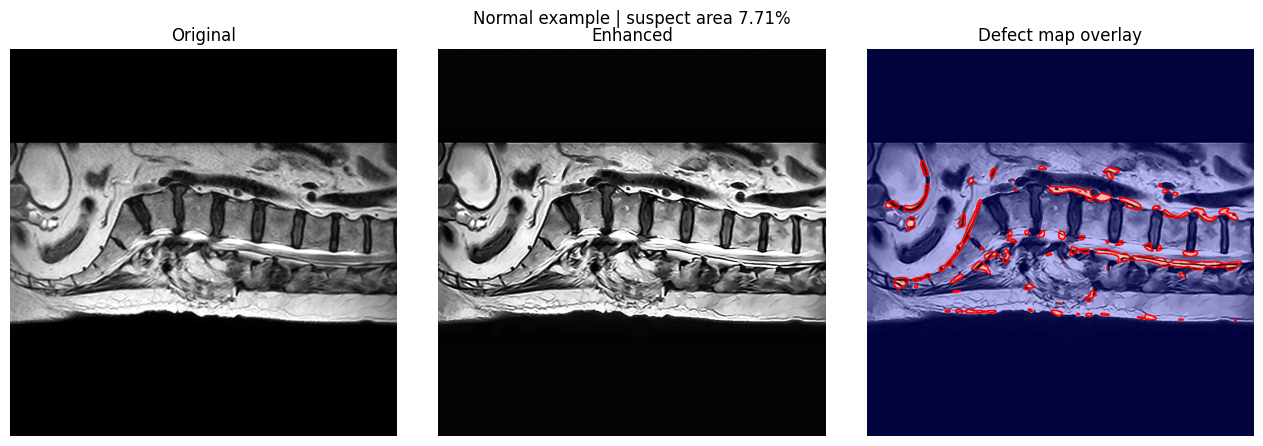

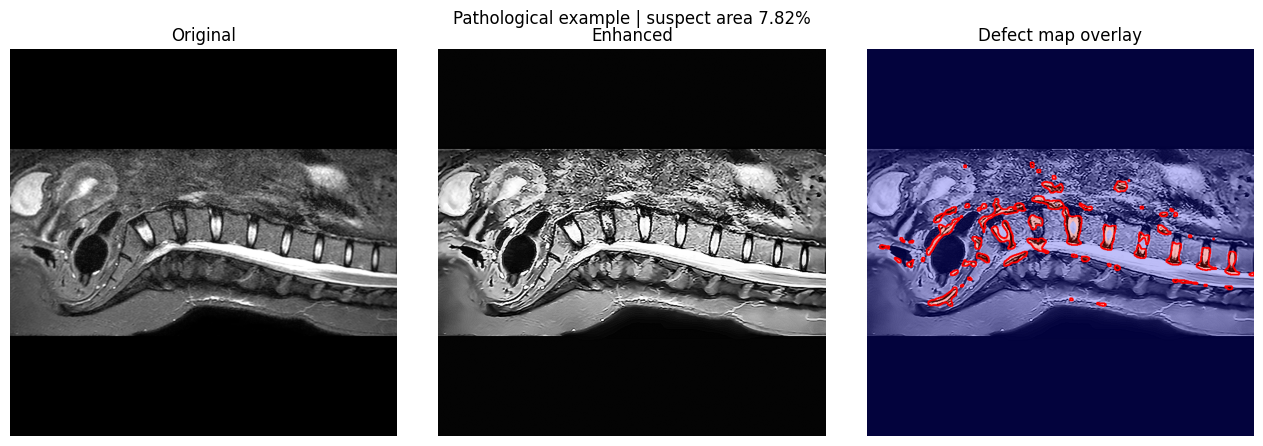

In [ ]:
# ---- Quick sanity check: enhancement + classical defect map on one normal and one pathological slice ----
def preview(rec, title):
    u8 = normalize_u8(rec["array"])
    enh = enhance(u8)
    result = segment_defects(enh)
    overlay = draw_overlay(enh, result["defect_mask"])

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    axes[0].imshow(u8, cmap="gray"); axes[0].set_title("Original")
    axes[1].imshow(enh, cmap="gray"); axes[1].set_title("Enhanced")
    axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); axes[2].set_title("Defect map overlay")
    for ax in axes: ax.axis("off")
    fig.suptitle(f"{title} | suspect area {result['suspect_area_pct']:.2f}%")
    plt.tight_layout(); plt.show()

normal_example = next(r for r in slice_records if r["label"] == 0)
patho_example = next(r for r in slice_records if r["label"] == 1)
preview(normal_example, "Normal example")
preview(patho_example, "Pathological example")

In [ ]:
# ---- CNN classifier ----
class SpineCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )
        self.gradcam_layer_name = "features.12"
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(256, 64), nn.ReLU(inplace=True),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        f = self.features(x)
        pooled = self.pool(f).flatten(1)
        return self.classifier(pooled)

model = SpineCNN().to(DEVICE)
print(model)

SpineCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128,

In [ ]:
# ---- Grad-CAM ----
class GradCAM:
    def __init__(self, model, target_layer_name=None):
        self.model = model.eval()
        target_layer_name = target_layer_name or getattr(model, "gradcam_layer_name", None)
        self.target_layer = dict(model.named_modules())[target_layer_name]
        self.activations = None
        self.gradients = None
        self.target_layer.register_forward_hook(self._save_activation)
        self.target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, x, class_idx=None):
        logits = self.model(x)
        probs = F.softmax(logits, dim=1)
        if class_idx is None:
            class_idx = int(probs.argmax(dim=1).item())
        self.model.zero_grad()
        logits[0, class_idx].backward(retain_graph=True)
        grads = self.gradients[0]
        acts = self.activations[0]
        weights = grads.mean(dim=(1, 2))
        cam = torch.zeros(acts.shape[1:], dtype=torch.float32)
        for c, w in enumerate(weights):
            cam += w * acts[c]
        cam = F.relu(cam)
        cam = cam / (cam.max() + 1e-8)
        cam = cam.cpu().numpy()
        cam = cv2.resize(cam, (x.shape[-1], x.shape[-2]))
        return cam, class_idx, probs.detach().cpu().numpy()[0]

def overlay_heatmap(img_u8, cam, alpha=0.45):
    heat = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    base = cv2.cvtColor(img_u8, cv2.COLOR_GRAY2BGR)
    return cv2.addWeighted(base, 1 - alpha, heat, alpha, 0)

In [ ]:
# ---- Training loop ----
def run_epoch(model, loader, device, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    losses, y_true, y_pred = [], [], []
    loss_fn = nn.CrossEntropyLoss()
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.set_grad_enabled(train_mode):
            logits = model(x)
            loss = loss_fn(logits, y)
            if train_mode:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
        losses.append(loss.item())
        y_true += y.cpu().tolist()
        y_pred += logits.argmax(1).cpu().tolist()
    return {"loss": float(np.mean(losses)) if losses else 0.0,
            "acc": accuracy_score(y_true, y_pred) if y_true else 0.0,
            "f1": f1_score(y_true, y_pred, zero_division=0) if y_true else 0.0,
            "y_true": y_true, "y_pred": y_pred}

In [ ]:
# ---- Run training ----
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

best_f1 = -1
ckpt_path = f"{CHECKPOINT_DIR}/best_model.pt"
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

for epoch in tqdm(range(1, NUM_EPOCHS + 1)):
    tr = run_epoch(model, train_dl, DEVICE, optimizer)
    va = run_epoch(model, val_dl, DEVICE, optimizer=None)
    scheduler.step(va["f1"])
    history["train_loss"].append(tr["loss"]); history["val_loss"].append(va["loss"])
    history["train_acc"].append(tr["acc"]); history["val_acc"].append(va["acc"])
    history["val_f1"].append(va["f1"])
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | train loss {tr['loss']:.3f} acc {tr['acc']:.3f} "
          f"| val loss {va['loss']:.3f} acc {va['acc']:.3f} f1 {va['f1']:.3f}")
    if va["f1"] > best_f1:
        best_f1 = va["f1"]
        torch.save({"model_state": model.state_dict()}, ckpt_path)
        print(f"  -> saved new best checkpoint (val f1={best_f1:.3f})")

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch 01/25 | train loss 0.687 acc 0.484 | val loss 0.697 acc 0.500 f1 0.000
  -> saved new best checkpoint (val f1=0.000)
Epoch 02/25 | train loss 0.658 acc 0.627 | val loss 0.672 acc 0.500 f1 0.667
  -> saved new best checkpoint (val f1=0.667)
Epoch 03/25 | train loss 0.657 acc 0.587 | val loss 0.695 acc 0.694 f1 0.621
Epoch 04/25 | train loss 0.629 acc 0.643 | val loss 0.722 acc 0.750 f1 0.667
Epoch 05/25 | train loss 0.616 acc 0.675 | val loss 0.683 acc 0.528 f1 0.605
Epoch 06/25 | train loss 0.601 acc 0.722 | val loss 0.664 acc 0.639 f1 0.723
  -> saved new best checkpoint (val f1=0.723)
Epoch 07/25 | train loss 0.582 acc 0.690 | val loss 0.838 acc 0.361 f1 0.207
Epoch 08/25 | train loss 0.563 acc 0.738 | val loss 0.889 acc 0.444 f1 0.231
Epoch 09/25 | train loss 0.563 acc 0.722 | val loss 0.970 acc 0.444 f1 0.333
Epoch 10/25 | train loss 0.529 acc 0.746 | val loss 0.845 acc 0.389 f1 0.421
Epoch 11/25 | train loss 0.507 acc 0.802 | val loss 0.930 acc 0.361 f1 0.378
Epoch 12/25 | t

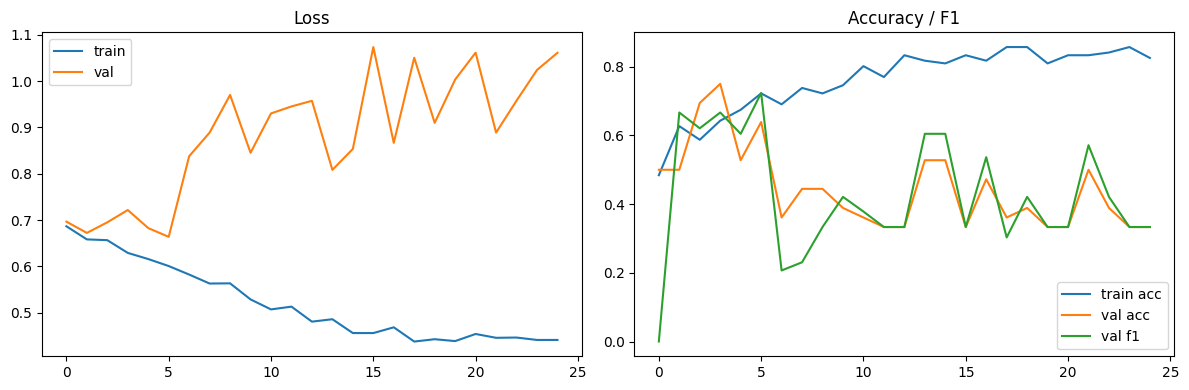

In [ ]:
# ---- Training curves ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train"); axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(history["train_acc"], label="train acc"); axes[1].plot(history["val_acc"], label="val acc")
axes[1].plot(history["val_f1"], label="val f1")
axes[1].set_title("Accuracy / F1"); axes[1].legend()
plt.tight_layout(); plt.show()

In [ ]:
# ---- Evaluate best checkpoint on held-out test patients ----
ckpt = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
te = run_epoch(model, test_dl, DEVICE, optimizer=None)
print(f"Test accuracy: {te['acc']:.3f} | Test F1: {te['f1']:.3f}")
print(confusion_matrix(te["y_true"], te["y_pred"]))
print(classification_report(te["y_true"], te["y_pred"], target_names=["Normal", "Pathological"], zero_division=0))

Test accuracy: 0.667 | Test F1: 0.750
[[3 6]
 [0 9]]
              precision    recall  f1-score   support

      Normal       1.00      0.33      0.50         9
Pathological       0.60      1.00      0.75         9

    accuracy                           0.67        18
   macro avg       0.80      0.67      0.62        18
weighted avg       0.80      0.67      0.62        18



In [ ]:
# ---- Full prediction + defect visualization pipeline ----
cam_engine = GradCAM(model)

def analyze_slice(raw_slice):
    u8 = normalize_u8(raw_slice)
    enh = enhance(u8)
    enh_resized = resize_square(enh, IMAGE_SIZE)

    classical = segment_defects(enh)

    tensor = torch.from_numpy(enh_resized).float().unsqueeze(0).unsqueeze(0).to(DEVICE) / 255.0
    cam, class_idx, probs = cam_engine(tensor)
    cam_full = cv2.resize(cam, (enh.shape[1], enh.shape[0]))

    label = LABEL_NAMES[class_idx]
    confidence = float(probs[class_idx])
    gradcam_overlay = overlay_heatmap(enh, cam_full)

    combined = (classical["anomaly_map"].astype(np.float32) / 255.0) * cam_full
    combined = (combined / (combined.max() + 1e-8) * 255).astype(np.uint8)
    combined = cv2.bitwise_and(combined, combined, mask=classical["body_mask"])

    return {"original_u8": u8, "enhanced_u8": enh, "predicted_label": label,
            "confidence": confidence, "suspect_area_pct": classical["suspect_area_pct"],
            "gradcam_overlay": gradcam_overlay, "combined_map": combined,
            "n_defect_regions": len(classical["contours"])}

def show_result(result, title=""):
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    axes[0].imshow(result["original_u8"], cmap="gray"); axes[0].set_title("Original")
    axes[1].imshow(result["enhanced_u8"], cmap="gray"); axes[1].set_title("Enhanced")
    axes[2].imshow(result["combined_map"], cmap="jet"); axes[2].set_title("Defect confidence map")
    axes[3].imshow(cv2.cvtColor(result["gradcam_overlay"], cv2.COLOR_BGR2RGB))
    axes[3].set_title(f"{result['predicted_label']} ({result['confidence']*100:.1f}%)")
    for ax in axes: ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout(); plt.show()
    print(f"Prediction: {result['predicted_label']} | confidence {result['confidence']*100:.1f}% "
          f"| suspect area {result['suspect_area_pct']:.2f}% | {result['n_defect_regions']} region(s)")

In [ ]:
# Disables in-place operations so Grad-CAM hooks can track gradients safely
for module in model.modules():
    if hasattr(module, 'inplace'):
        module.inplace = False

print("[✓] Model patched. Ready for Grad-CAM inference!")

[✓] Model patched. Ready for Grad-CAM inference!


In [12]:
# ---- Optional: batch-process a whole patient folder and save a summary.json ----
def run_batch(input_path, out_dir=REPORT_DIR, n_slices=1):
    os.makedirs(out_dir, exist_ok=True)
    summary = []
    for f in collect_input_files(input_path):
        try:
            slices = load_middle_slices(f, n_slices=n_slices)
        except Exception as e:
            print(f"[WARN] skipping {f}: {e}"); continue
        base = os.path.splitext(os.path.splitext(os.path.basename(f))[0])[0]
        for i, sl in enumerate(slices):
            if sl.size == 0 or np.all(sl == 0):
                continue
            result = analyze_slice(sl)
            fig_path = os.path.join(out_dir, f"{base}_slice{i}.png")
            fig, axes = plt.subplots(1, 4, figsize=(18, 5))
            axes[0].imshow(result["original_u8"], cmap="gray"); axes[0].set_title("Original")
            axes[1].imshow(result["enhanced_u8"], cmap="gray"); axes[1].set_title("Enhanced")
            axes[2].imshow(result["combined_map"], cmap="jet"); axes[2].set_title("Defect confidence map")
            axes[3].imshow(cv2.cvtColor(result["gradcam_overlay"], cv2.COLOR_BGR2RGB))
            axes[3].set_title(f"{result['predicted_label']} ({result['confidence']*100:.1f}%)")
            for ax in axes: ax.axis("off")
            fig.suptitle(f"{base} (slice {i})")
            plt.tight_layout(); plt.savefig(fig_path, dpi=150); plt.close(fig)
            summary.append({"file": f, "slice": i, "prediction": result["predicted_label"],
                             "confidence": result["confidence"],
                             "suspect_area_pct": result["suspect_area_pct"],
                             "n_defect_regions": result["n_defect_regions"], "figure": fig_path})
    with open(os.path.join(out_dir, "summary.json"), "w") as fh:
        json.dump(summary, fh, indent=2)
    print(f"Saved {len(summary)} report figures + summary.json to {out_dir}")
    return summary

# example:
# run_batch(sample_patient_dir)